In [1]:
# RPKM weights for  abundance-weighted KDE 
import os
import pandas as pd
import numpy as np

REVISIONS = "/Users/skoog/Desktop/Revisions"

# Enveloped viral lineages to to drop 
DROP_ORDERS = set()       
DROP_FAMILIES = {
    "Pleolipoviridae", "Poxviridae", "Lipothrixviridae", "Globuloviridae", "Bicaudaviridae", "Fuselloviridae",
    "Ascoviridae", "Kitaviridae", "Unclassified Pokkesviricetes", "Asfarviridae", "Unclassified Herpesvirales",
    "Herpesviridae", "Unclassified Lefavirales", "Unclassified Bunyavirales", "Tristromaviridae", "Baculoviridae",
    "Rhabdoviridae", "Unclassified Mononegavirales", "Unclassified Nidovirales", "Alloherpesviridae", "Mymonaviridae",
    "Cystoviridae", "Phenuiviridae", "Nudiviridae", "Unclassified Haloruvirales",
}

RPKM_FILES = {
    "Picturesque_lake":            ("Picturesque_lake_split_by_contig_faa_updated_revisions_exact_besthit",            "Picturesque_viruses_rpkm_mcf0.75.tsv"),        # given
    "Lake_Bitter_1":               ("Lake_Bitter_1_split_by_contig_faa_updated_revisions_exact_besthit",               "Lake_bitter_B1_viruses_rpkm_mcf0.75.tsv"),     # given
    "Cock_soda_lake":              ("Cock_soda_lake_split_by_contig_faa_updated_revisions_exact_besthit",              "Cock_soda_lake_viruses_rpkm_mcf0.75.tsv"),     # given
    "Lake_tanatar_TC":             ("Lake_tanatar_TC_split_by_contig_faa_updated_revisions_exact_besthit",             "Lake_tanatar_TC_viruses_rpkm_mcf0.75.tsv"),    # VERIFY filename
    "Tanatar_5":                   ("Tanatar_5_split_by_contig_faa_updated_revisions_exact_besthit",                   "Tanatar_5_viruses_rpkm_mcf0.75.tsv"),          # VERIFY filename
    "Cueva_de_la_mora_lake_11m":   ("Cueva_de_la_mora_lake_11m_split_by_contig_faa_updated_revisions_exact_besthit",   "Cueva_de_la_mora_lake_11m_viruses_rpkm_mcf0.75.tsv"),  # VERIFY filename
    "Cueva_de_la_mora_lake_35m":   ("Cueva_de_la_mora_lake_35m_split_by_contig_faa_updated_revisions_exact_besthit",   "Cueva_de_la_mora_lake_35m_viruses_rpkm_mcf0.75.tsv"),  # VERIFY filename
    "Cueva_de_la_mora_lake_3m":    ("Cueva_de_la_mora_lake_3m_split_by_contig_faa_updated_revisions_exact_besthit",    "Cueva_de_la_mora_lake_3m_viruses_rpkm_mcf0.75.tsv"),   # VERIFY filename
    "Lost_city":                   ("Lost_city_split_by_contig_faa_updated_revisions_exact_besthit",                   "Lost_city_viruses_rpkm_mcf0.75.tsv"),          # confirmed
    "Malaren_B":                   ("Malaren_B_split_by_contig_faa_updated_revisions_exact_besthit",                   "Malaren_B_viruses_rpkm_mcf0.75.tsv"),          # given
    "Lake_Victoria":               ("Lake_Victoria_split_by_contig_faa_updated_revisions_exact_besthit",               "Lake_Victoria_lake_viruses_rpkm_mcf0.75.tsv"),  # given
    "Lake_Soyang":                 ("Lake_Soyang_viruses_split_by_contig_faa_besthit",                                 "Lake_Soyang_viruses_rpkm_mcf0.75.tsv"),        # given
}

#merging freshwater data
GENOMAD_VS2_SUMMARY = "all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_virsorter2_virus_summary.tsv"

FRESHWATER_META = {
    "Malaren B":     {"Environment_Type": "Freshwater", "pH": 7.0, "Salinity": 0.0},
    "Lake Victoria": {"Environment_Type": "Freshwater", "pH": 7.0, "Salinity": 0.0},
    "Lake Soyang":   {"Environment_Type": "Freshwater", "pH": 7.0, "Salinity": 0.0},
}

def load_rpkm(env_key):
    """Read a CoverM RPKM TSV for one environment and return [contig_id, rpkm].
    Auto-detects the contig-ID column (first column) and the RPKM column
    (column whose name contains 'rpkm'; otherwise the first numeric column).
    Missing file -> empty frame (those viruses fall back to weight 1.0)."""
    folder, fname = RPKM_FILES[env_key]
    path = os.path.join(REVISIONS, folder, fname)
    try:
        t = pd.read_csv(path, sep="\t")
    except FileNotFoundError:
        print(f"[RPKM] WARNING: not found for {env_key}: {path}  -> weights default to 1.0")
        return pd.DataFrame({"contig_id": [], "rpkm": []})
    id_col = t.columns[0]
    rpkm_cols = [c for c in t.columns if "rpkm" in c.lower()]
    val_col = rpkm_cols[0] if rpkm_cols else t.select_dtypes("number").columns[0]
    out = t[[id_col, val_col]].copy()
    out.columns = ["contig_id", "rpkm"]
    out["contig_id"] = out["contig_id"].astype(str)
    # match the pI side, which strips a trailing .faa from contig_id
    out["contig_id"] = out["contig_id"].str.replace(".faa", "", regex=False)
    n = len(out)
    print(f"[RPKM] {env_key}: loaded {n} contig weights from {fname}" if n else f"[RPKM] {env_key}: empty")
    return out

def wquantile(values, weights, q):
    """Weighted quantile; q=0.5 -> weighted median. Equal weights -> ordinary quantile."""
    import numpy as np
    v = np.asarray(values, float); w = np.asarray(weights, float)
    m = np.isfinite(v) & np.isfinite(w) & (w > 0); v, w = v[m], w[m]
    if v.size == 0: return float("nan")
    o = np.argsort(v); v, w = v[o], w[o]
    cw = np.cumsum(w) - 0.5 * w; cw /= w.sum()
    return float(np.interp(q, cw, v))


In [2]:
import os
import csv
import statistics
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis


# Directory containing the .faa files
faa_dir = "/Users/skoog/Desktop/Revisions/Picturesque_lake_split_by_contig_faa_updated_revisions_exact_besthit/"

# Output CSV file to store results
output_csv = "/Users/skoog/Desktop/Revisions/Picturesque_lake_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Picturesque_lake_viromes_updated.csv"

# Initialize a list to store results
results = []

# Loop through each .faa file in the directory
for faa_file in os.listdir(faa_dir):
    if faa_file.endswith(".faa"):  
        file_path = os.path.join(faa_dir, faa_file)
        
        pi_values = []  # List to store pI values for this file
        
        # Read and analyze protein sequences
        for record in SeqIO.parse(file_path, "fasta"):
            protein_seq = str(record.seq)
            
            if protein_seq:  
                try:
                    analysis = ProteinAnalysis(protein_seq)
                    pi_values.append(analysis.isoelectric_point())  
                except Exception as e:
                    print(f"Skipping sequence {record.id} due to error: {e}")

        # Compute median pI for this .faa file
        median_pi = statistics.median(pi_values) if pi_values else 0
        results.append([faa_file, median_pi, len(pi_values)])


# Save results to CSV
with open(output_csv, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["File", "Median_pI", "n_structural"])  # Write header
    writer.writerows(results)

#print(f"Results saved to {output_csv}")
import pandas as pd

Picturesque_lake_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Picturesque_lake_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Picturesque_lake_viromes_updated.csv")

Picturesque_lake_df.rename(columns={Picturesque_lake_df.columns[0]: "contig_id"}, inplace=True)
Picturesque_lake_df["contig_id"] = Picturesque_lake_df["contig_id"].str.replace(".faa", "", regex=False)
Picturesque_lake_df["name_full"] = "Picturesque Lake"

# Specify the file path with taxonomy information from genomad
taxonomy_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Picturesque_lake_split_by_contig_faa_updated_revisions_exact_besthit/all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_virus_summary.tsv", sep="\t", header=0)


# Rename the first column to 'Viral_ID'
first_col = taxonomy_df.columns[0]
taxonomy_df.rename(columns={first_col: 'Viral_ID'}, inplace=True)

# Split the taxonomy column into separate columns
taxonomy_split = taxonomy_df['taxonomy'].str.split(';', expand=True)

# Assign the new columns to the dataframe
taxonomy_df[['virus', 'realm', 'kingdom', 'phylum', 'class', 'order', 'family']] = taxonomy_split

taxonomy_df.rename(columns={taxonomy_df.columns[0]: "contig_id"}, inplace=True)

def fill_family(row):
    if pd.notna(row['family']) and row['family'].strip() != '':
        return row['family']
    # Check from most specific to broader taxonomic levels
    for level in [ 'order', 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['family'] = taxonomy_df.apply(fill_family, axis=1)

def fill_family(row):
    if pd.notna(row['order']) and row['order'].strip() != '':
        return row['order']
    # Check from most specific to broader taxonomic levels
    for level in [ 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['order'] = taxonomy_df.apply(fill_family, axis=1)


import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Merge the dataframes 
for _d in (Picturesque_lake_df, taxonomy_df):
    _d["contig_id"] = _d["contig_id"].astype(str).str.replace("|", "_", regex=False)
Picturesque_lake_taxonomy_merged_df = Picturesque_lake_df.merge(taxonomy_df, on="contig_id", how="inner")  # Use 'outer' if you want all rows

# Attach per-virus RPKM (CoverM) as KDE weights 
Picturesque_lake_taxonomy_merged_df = Picturesque_lake_taxonomy_merged_df.merge(load_rpkm("Picturesque_lake"), on="contig_id", how="left")


#display(Picturesque_lake_taxonomy_merged_df)

[RPKM] Picturesque_lake: loaded 249 contig weights from Picturesque_viruses_rpkm_mcf0.75.tsv


In [3]:
import os
import csv
import statistics
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis


faa_dir = "/Users/skoog/Desktop/Revisions/Lake_tanatar_TC_split_by_contig_faa_updated_revisions_exact_besthit/"

# Output CSV file to store results
output_csv = "/Users/skoog/Desktop/Revisions/Lake_tanatar_TC_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Lake_tanatar_TC_viromes_updated.csv"

# Initialize a list to store results
results = []

# Loop through each .faa file in the directory
for faa_file in os.listdir(faa_dir):
    if faa_file.endswith(".faa"):  # Process only .faa files
        file_path = os.path.join(faa_dir, faa_file)
        
        pi_values = []  # List to store pI values for this file
        
        # Read and analyze protein sequences
        for record in SeqIO.parse(file_path, "fasta"):
            protein_seq = str(record.seq)
            
            if protein_seq:  # Ensure sequence is not empty
                try:
                    analysis = ProteinAnalysis(protein_seq)
                    pi_values.append(analysis.isoelectric_point())  # Compute pI
                except Exception as e:
                    print(f"Skipping sequence {record.id} due to error: {e}")

        # Compute median pI for this .faa file
        median_pi = statistics.median(pi_values) if pi_values else 0
        results.append([faa_file, median_pi, len(pi_values)])


# Save results to CSV
with open(output_csv, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["File", "Median_pI", "n_structural"])  # Write header
    writer.writerows(results)

#print(f"Results saved to {output_csv}")
import pandas as pd

Lake_tanatar_TC_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Lake_tanatar_TC_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Lake_tanatar_TC_viromes_updated.csv")

Lake_tanatar_TC_df.rename(columns={Lake_tanatar_TC_df.columns[0]: "contig_id"}, inplace=True)
Lake_tanatar_TC_df["contig_id"] = Lake_tanatar_TC_df["contig_id"].str.replace(".faa", "", regex=False)
Lake_tanatar_TC_df["name_full"] = "Lake Tanatar trona crystallizer"

import pandas as pd

# Specify the file path with taxonomy information from genomad
taxonomy_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Lake_tanatar_TC_split_by_contig_faa_updated_revisions_exact_besthit/all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_virus_summary.tsv", sep="\t", header=0)


# Rename the first column to 'Viral_ID'
first_col = taxonomy_df.columns[0]
taxonomy_df.rename(columns={first_col: 'Viral_ID'}, inplace=True)

# Split the taxonomy column into separate columns
taxonomy_split = taxonomy_df['taxonomy'].str.split(';', expand=True)

# Assign the new columns to the dataframe
taxonomy_df[['virus', 'realm', 'kingdom', 'phylum', 'class', 'order', 'family']] = taxonomy_split

taxonomy_df.rename(columns={taxonomy_df.columns[0]: "contig_id"}, inplace=True)

def fill_family(row):
    if pd.notna(row['family']) and row['family'].strip() != '':
        return row['family']
    # Check from most specific to broader taxonomic levels
    for level in [ 'order', 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['family'] = taxonomy_df.apply(fill_family, axis=1)

def fill_family(row):
    if pd.notna(row['order']) and row['order'].strip() != '':
        return row['order']
    # Check from most specific to broader taxonomic levels
    for level in [ 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['order'] = taxonomy_df.apply(fill_family, axis=1)

# Display the first few rows

# Or if display truncates rows/columns:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Merge the dataframes 
for _d in (Lake_tanatar_TC_df, taxonomy_df):
    _d["contig_id"] = _d["contig_id"].astype(str).str.replace("|", "_", regex=False)
Lake_tanatar_TC_taxonomy_merged_df = Lake_tanatar_TC_df.merge(taxonomy_df, on="contig_id", how="inner")  # Use 'outer' if you want all rows

# Attach per-virus RPKM (CoverM) as KDE weights — file lives in this lake's Revisions folder
Lake_tanatar_TC_taxonomy_merged_df = Lake_tanatar_TC_taxonomy_merged_df.merge(load_rpkm("Lake_tanatar_TC"), on="contig_id", how="left")


#display(Lake_tanatar_TC_taxonomy_merged_df)

[RPKM] Lake_tanatar_TC: loaded 232 contig weights from Lake_tanatar_TC_viruses_rpkm_mcf0.75.tsv


In [4]:
import os
import csv
import statistics
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis


# Directory containing the .faa files
faa_dir = "/Users/skoog/Desktop/Revisions/Tanatar_5_split_by_contig_faa_updated_revisions_exact_besthit/"

# Output CSV file to store results
output_csv = "/Users/skoog/Desktop/Revisions/Tanatar_5_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Tanatar_5_viromes_updated.csv"

# Initialize a list to store results
results = []

# Loop through each .faa file in the directory
for faa_file in os.listdir(faa_dir):
    if faa_file.endswith(".faa"):  # Process only .faa files
        file_path = os.path.join(faa_dir, faa_file)
        
        pi_values = []  # List to store pI values for this file
        
        # Read and analyze protein sequences
        for record in SeqIO.parse(file_path, "fasta"):
            protein_seq = str(record.seq)
            
            if protein_seq:  # Ensure sequence is not empty
                try:
                    analysis = ProteinAnalysis(protein_seq)
                    pi_values.append(analysis.isoelectric_point())  # Compute pI
                except Exception as e:
                    print(f"Skipping sequence {record.id} due to error: {e}")

        # Compute median pI for this .faa file
        median_pi = statistics.median(pi_values) if pi_values else 0
        results.append([faa_file, median_pi, len(pi_values)])


# Save results to CSV
with open(output_csv, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["File", "Median_pI", "n_structural"])  # Write header
    writer.writerows(results)

#print(f"Results saved to {output_csv}")
import pandas as pd

Tanatar_5_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Tanatar_5_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Tanatar_5_viromes_updated.csv")

Tanatar_5_df.rename(columns={Tanatar_5_df.columns[0]: "contig_id"}, inplace=True)
Tanatar_5_df["contig_id"] = Tanatar_5_df["contig_id"].str.replace(".faa", "", regex=False)
Tanatar_5_df["name_full"] = "Lake Tanatar-5"

import pandas as pd

# Specify the file path with taxonomy information from genomad
taxonomy_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Tanatar_5_split_by_contig_faa_updated_revisions_exact_besthit/all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_virus_summary.tsv", sep="\t", header=0)


# Rename the first column to 'Viral_ID'
first_col = taxonomy_df.columns[0]
taxonomy_df.rename(columns={first_col: 'Viral_ID'}, inplace=True)

# Split the taxonomy column into separate columns
taxonomy_split = taxonomy_df['taxonomy'].str.split(';', expand=True)

# Assign the new columns to the dataframe
taxonomy_df[['virus', 'realm', 'kingdom', 'phylum', 'class', 'order', 'family']] = taxonomy_split

taxonomy_df.rename(columns={taxonomy_df.columns[0]: "contig_id"}, inplace=True)

def fill_family(row):
    if pd.notna(row['family']) and row['family'].strip() != '':
        return row['family']
    # Check from most specific to broader taxonomic levels
    for level in [ 'order', 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['family'] = taxonomy_df.apply(fill_family, axis=1)

def fill_family(row):
    if pd.notna(row['order']) and row['order'].strip() != '':
        return row['order']
    # Check from most specific to broader taxonomic levels
    for level in [ 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['order'] = taxonomy_df.apply(fill_family, axis=1)

# Display the first few rows

# Or if display truncates rows/columns:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Merge the dataframes 
for _d in (Tanatar_5_df, taxonomy_df):
    _d["contig_id"] = _d["contig_id"].astype(str).str.replace("|", "_", regex=False)
Tanatar_5_taxonomy_merged_df = Tanatar_5_df.merge(taxonomy_df, on="contig_id", how="inner")  # Use 'outer' if you want all rows

# Attach per-virus RPKM (CoverM) as KDE weights — file lives in this lake's Revisions folder
Tanatar_5_taxonomy_merged_df = Tanatar_5_taxonomy_merged_df.merge(load_rpkm("Tanatar_5"), on="contig_id", how="left")


#display(Tanatar_5_taxonomy_merged_df)

[RPKM] Tanatar_5: loaded 540 contig weights from Tanatar_5_viruses_rpkm_mcf0.75.tsv


In [5]:
import os
import csv
import statistics
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis


# Directory containing the .faa files
faa_dir = "/Users/skoog/Desktop/Revisions/Lake_Bitter_1_split_by_contig_faa_updated_revisions_exact_besthit/"

# Output CSV file to store results
output_csv = "/Users/skoog/Desktop/Revisions/Lake_Bitter_1_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Lake_Bitter_viromes_updated.csv"

# Initialize a list to store results
results = []

# Loop through each .faa file in the directory
for faa_file in os.listdir(faa_dir):
    if faa_file.endswith(".faa"):  # Process only .faa files
        file_path = os.path.join(faa_dir, faa_file)
        
        pi_values = []  # List to store pI values for this file
        
        # Read and analyze protein sequences
        for record in SeqIO.parse(file_path, "fasta"):
            protein_seq = str(record.seq)
            
            if protein_seq:  # Ensure sequence is not empty
                try:
                    analysis = ProteinAnalysis(protein_seq)
                    pi_values.append(analysis.isoelectric_point())  # Compute pI
                except Exception as e:
                    print(f"Skipping sequence {record.id} due to error: {e}")

        # Compute median pI for this .faa file
        median_pi = statistics.median(pi_values) if pi_values else 0
        results.append([faa_file, median_pi, len(pi_values)])

        #print(f"Processed {faa_file}: Median pI = {median_pi:.2f}")

# Save results to CSV
with open(output_csv, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["File", "Median_pI", "n_structural"])  # Write header
    writer.writerows(results)

#print(f"Results saved to {output_csv}")
import pandas as pd

Lake_bitter_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Lake_Bitter_1_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Lake_Bitter_viromes_updated.csv")

Lake_bitter_df.rename(columns={Lake_bitter_df.columns[0]: "contig_id"}, inplace=True)
Lake_bitter_df["contig_id"] = Lake_bitter_df["contig_id"].str.replace(".faa", "", regex=False)
Lake_bitter_df["name_full"] = "Lake Bitter-1"

import pandas as pd

# Specify the file path with taxonomy information from genomad
taxonomy_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Lake_Bitter_1_split_by_contig_faa_updated_revisions_exact_besthit/all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_virus_summary.tsv", sep="\t", header=0)


# Rename the first column to 'Viral_ID'
first_col = taxonomy_df.columns[0]
taxonomy_df.rename(columns={first_col: 'Viral_ID'}, inplace=True)

# Split the taxonomy column into separate columns
taxonomy_split = taxonomy_df['taxonomy'].str.split(';', expand=True)

# Assign the new columns to the dataframe
taxonomy_df[['virus', 'realm', 'kingdom', 'phylum', 'class', 'order', 'family']] = taxonomy_split

taxonomy_df.rename(columns={taxonomy_df.columns[0]: "contig_id"}, inplace=True)

def fill_family(row):
    if pd.notna(row['family']) and row['family'].strip() != '':
        return row['family']
    # Check from most specific to broader taxonomic levels
    for level in [ 'order', 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['family'] = taxonomy_df.apply(fill_family, axis=1)

def fill_family(row):
    if pd.notna(row['order']) and row['order'].strip() != '':
        return row['order']
    # Check from most specific to broader taxonomic levels
    for level in [ 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['order'] = taxonomy_df.apply(fill_family, axis=1)

# Display the first few rows

# Or if display truncates rows/columns:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Merge the dataframes 
for _d in (Lake_bitter_df, taxonomy_df):
    _d["contig_id"] = _d["contig_id"].astype(str).str.replace("|", "_", regex=False)
Lake_bitter_df_taxonomy_merged_df = Lake_bitter_df.merge(taxonomy_df, on="contig_id", how="inner")  # Use 'outer' if you want all rows

# Attach per-virus RPKM (CoverM) as KDE weights — file lives in this lake's Revisions folder
Lake_bitter_df_taxonomy_merged_df = Lake_bitter_df_taxonomy_merged_df.merge(load_rpkm("Lake_Bitter_1"), on="contig_id", how="left")


#display(Lake_bitter_df_taxonomy_merged_df)

[RPKM] Lake_Bitter_1: loaded 88 contig weights from Lake_bitter_B1_viruses_rpkm_mcf0.75.tsv


In [6]:
import os
import csv
import statistics
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis

#calculate the median isolelectric point of each f the 7813 dereplicated viruses identified in WATL brine metagenomes

# Directory containing the .faa files
faa_dir = "/Users/skoog/Desktop/Revisions/Cueva_de_la_mora_lake_11m_split_by_contig_faa_updated_revisions_exact_besthit/"

# Output CSV file to store results
output_csv = "/Users/skoog/Desktop/Revisions/Cueva_de_la_mora_lake_11m_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Lake_Bitter_viromes_updated.csv"

# Initialize a list to store results
results = []

# Loop through each .faa file in the directory
for faa_file in os.listdir(faa_dir):
    if faa_file.endswith(".faa"):  # Process only .faa files
        file_path = os.path.join(faa_dir, faa_file)
        
        pi_values = []  # List to store pI values for this file
        
        # Read and analyze protein sequences
        for record in SeqIO.parse(file_path, "fasta"):
            protein_seq = str(record.seq)
            
            if protein_seq:  # Ensure sequence is not empty
                try:
                    analysis = ProteinAnalysis(protein_seq)
                    pi_values.append(analysis.isoelectric_point())  # Compute pI
                except Exception as e:
                    print(f"Skipping sequence {record.id} due to error: {e}")

        # Compute median pI for this .faa file
        median_pi = statistics.median(pi_values) if pi_values else 0
        results.append([faa_file, median_pi, len(pi_values)])

        #print(f"Processed {faa_file}: Median pI = {median_pi:.2f}")

# Save results to CSV
with open(output_csv, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["File", "Median_pI", "n_structural"])  # Write header
    writer.writerows(results)

#print(f"Results saved to {output_csv}")
import pandas as pd

Cueva_de_la_mora_lake_11m_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Cueva_de_la_mora_lake_11m_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Lake_Bitter_viromes_updated.csv")

Cueva_de_la_mora_lake_11m_df.rename(columns={Cueva_de_la_mora_lake_11m_df.columns[0]: "contig_id"}, inplace=True)
Cueva_de_la_mora_lake_11m_df["contig_id"] = Cueva_de_la_mora_lake_11m_df["contig_id"].str.replace(".faa", "", regex=False)
Cueva_de_la_mora_lake_11m_df["name_full"] = "Cueva de la Mora lake - Chemocline (11m)"

import pandas as pd

# Specify the file path with taxonomy information from genomad
taxonomy_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Cueva_de_la_mora_lake_11m_split_by_contig_faa_updated_revisions_exact_besthit/all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_virus_summary.tsv", sep="\t", header=0)


# Rename the first column to 'Viral_ID'
first_col = taxonomy_df.columns[0]
taxonomy_df.rename(columns={first_col: 'contig_id'}, inplace=True)

import numpy as np

taxonomy_split = taxonomy_df['taxonomy'].str.split(';', expand=True)

taxonomy_df[['virus', 'realm', 'kingdom', 'phylum', 'class', 'order', 'family']] = (
    pd.DataFrame(taxonomy_split)
    .reindex(columns=range(7), fill_value=np.nan)
)


def fill_family(row):
    if pd.notna(row['family']) and row['family'].strip() != '':
        return row['family']
    # Check from most specific to broader taxonomic levels
    for level in [ 'order', 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['family'] = taxonomy_df.apply(fill_family, axis=1)

def fill_family(row):
    if pd.notna(row['order']) and row['order'].strip() != '':
        return row['order']
    # Check from most specific to broader taxonomic levels
    for level in [ 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['order'] = taxonomy_df.apply(fill_family, axis=1)


# Display the first few rows

# Or if display truncates rows/columns:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Merge the dataframes 
for _d in (Cueva_de_la_mora_lake_11m_df, taxonomy_df):
    _d["contig_id"] = _d["contig_id"].astype(str).str.replace("|", "_", regex=False)
Cueva_de_la_mora_lake_11m_taxonomy_merged_df = Cueva_de_la_mora_lake_11m_df.merge(taxonomy_df, on="contig_id", how="inner")  # Use 'outer' if you want all rows

# Attach per-virus RPKM (CoverM) as KDE weights — file lives in this lake's Revisions folder
Cueva_de_la_mora_lake_11m_taxonomy_merged_df = Cueva_de_la_mora_lake_11m_taxonomy_merged_df.merge(load_rpkm("Cueva_de_la_mora_lake_11m"), on="contig_id", how="left")


#display(Cueva_de_la_mora_lake_11m_taxonomy_merged_df)

[RPKM] Cueva_de_la_mora_lake_11m: loaded 42 contig weights from Cueva_de_la_mora_lake_11m_viruses_rpkm_mcf0.75.tsv


In [7]:
import os
import csv
import statistics
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis


# Directory containing the .faa files
faa_dir = "/Users/skoog/Desktop/Revisions/Cueva_de_la_mora_lake_35m_split_by_contig_faa_updated_revisions_exact_besthit/"

# Output CSV file to store results
output_csv = "/Users/skoog/Desktop/Revisions/Cueva_de_la_mora_lake_35m_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Lake_Bitter_viromes_updated.csv"

# Initialize a list to store results
results = []

# Loop through each .faa file in the directory
for faa_file in os.listdir(faa_dir):
    if faa_file.endswith(".faa"):  # Process only .faa files
        file_path = os.path.join(faa_dir, faa_file)
        
        pi_values = []  # List to store pI values for this file
        
        # Read and analyze protein sequences
        for record in SeqIO.parse(file_path, "fasta"):
            protein_seq = str(record.seq)
            
            if protein_seq:  # Ensure sequence is not empty
                try:
                    analysis = ProteinAnalysis(protein_seq)
                    pi_values.append(analysis.isoelectric_point())  # Compute pI
                except Exception as e:
                    print(f"Skipping sequence {record.id} due to error: {e}")

        # Compute median pI for this .faa file
        median_pi = statistics.median(pi_values) if pi_values else 0
        results.append([faa_file, median_pi, len(pi_values)])


# Save results to CSV
with open(output_csv, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["File", "Median_pI", "n_structural"])  # Write header
    writer.writerows(results)

#print(f"Results saved to {output_csv}")
import pandas as pd

Cueva_de_la_mora_lake_35m_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Cueva_de_la_mora_lake_35m_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Lake_Bitter_viromes_updated.csv")

Cueva_de_la_mora_lake_35m_df.rename(columns={Cueva_de_la_mora_lake_35m_df.columns[0]: "contig_id"}, inplace=True)
Cueva_de_la_mora_lake_35m_df["contig_id"] = Cueva_de_la_mora_lake_35m_df["contig_id"].str.replace(".faa", "", regex=False)
Cueva_de_la_mora_lake_35m_df["name_full"] = "Cueva de la Mora lake - Deep Anoxic Layer (35m)"

import pandas as pd

# Specify the file path with taxonomy information from genomad
taxonomy_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Cueva_de_la_mora_lake_35m_split_by_contig_faa_updated_revisions_exact_besthit/all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_virus_summary.tsv", sep="\t", header=0)


# Rename the first column to 'Viral_ID'
first_col = taxonomy_df.columns[0]
taxonomy_df.rename(columns={first_col: 'contig_id'}, inplace=True)

import numpy as np

taxonomy_split = taxonomy_df['taxonomy'].str.split(';', expand=True)

taxonomy_df[['virus', 'realm', 'kingdom', 'phylum', 'class', 'order', 'family']] = (
    pd.DataFrame(taxonomy_split)
    .reindex(columns=range(7), fill_value=np.nan)
)


def fill_family(row):
    if pd.notna(row['family']) and row['family'].strip() != '':
        return row['family']
    # Check from most specific to broader taxonomic levels
    for level in [ 'order', 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['family'] = taxonomy_df.apply(fill_family, axis=1)

def fill_family(row):
    if pd.notna(row['order']) and row['order'].strip() != '':
        return row['order']
    # Check from most specific to broader taxonomic levels
    for level in [ 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['order'] = taxonomy_df.apply(fill_family, axis=1)


# Display the first few rows

# Or if display truncates rows/columns:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Merge the dataframes 
for _d in (Cueva_de_la_mora_lake_35m_df, taxonomy_df):
    _d["contig_id"] = _d["contig_id"].astype(str).str.replace("|", "_", regex=False)
Cueva_de_la_mora_lake_35m_taxonomy_merged_df = Cueva_de_la_mora_lake_35m_df.merge(taxonomy_df, on="contig_id", how="inner")  # Use 'outer' if you want all rows

# Attach per-virus RPKM (CoverM) as KDE weights — file lives in this lake's Revisions folder
Cueva_de_la_mora_lake_35m_taxonomy_merged_df = Cueva_de_la_mora_lake_35m_taxonomy_merged_df.merge(load_rpkm("Cueva_de_la_mora_lake_35m"), on="contig_id", how="left")


#display(Cueva_de_la_mora_lake_35m_taxonomy_merged_df)

[RPKM] Cueva_de_la_mora_lake_35m: loaded 51 contig weights from Cueva_de_la_mora_lake_35m_viruses_rpkm_mcf0.75.tsv


In [8]:
import os
import csv
import statistics
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis


# Directory containing the .faa files
faa_dir = "/Users/skoog/Desktop/Revisions/Cueva_de_la_mora_lake_3m_split_by_contig_faa_updated_revisions_exact_besthit/"

# Output CSV file to store results
output_csv = "/Users/skoog/Desktop/Revisions/Cueva_de_la_mora_lake_3m_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Lake_Bitter_viromes_updated.csv"

# Initialize a list to store results
results = []

# Loop through each .faa file in the directory
for faa_file in os.listdir(faa_dir):
    if faa_file.endswith(".faa"):  # Process only .faa files
        file_path = os.path.join(faa_dir, faa_file)
        
        pi_values = []  # List to store pI values for this file
        
        # Read and analyze protein sequences
        for record in SeqIO.parse(file_path, "fasta"):
            protein_seq = str(record.seq)
            
            if protein_seq:  # Ensure sequence is not empty
                try:
                    analysis = ProteinAnalysis(protein_seq)
                    pi_values.append(analysis.isoelectric_point())  # Compute pI
                except Exception as e:
                    print(f"Skipping sequence {record.id} due to error: {e}")

        # Compute median pI for this .faa file
        median_pi = statistics.median(pi_values) if pi_values else 0
        results.append([faa_file, median_pi, len(pi_values)])

        #print(f"Processed {faa_file}: Median pI = {median_pi:.2f}")

# Save results to CSV
with open(output_csv, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["File", "Median_pI", "n_structural"])  # Write header
    writer.writerows(results)

#print(f"Results saved to {output_csv}")
import pandas as pd

Cueva_de_la_mora_lake_3m_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Cueva_de_la_mora_lake_3m_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Lake_Bitter_viromes_updated.csv")

Cueva_de_la_mora_lake_3m_df.rename(columns={Cueva_de_la_mora_lake_3m_df.columns[0]: "contig_id"}, inplace=True)
Cueva_de_la_mora_lake_3m_df["contig_id"] = Cueva_de_la_mora_lake_3m_df["contig_id"].str.replace(".faa", "", regex=False)
Cueva_de_la_mora_lake_3m_df["name_full"] = "Cueva de la Mora lake - Upper Oxic Layer (3m)"

import pandas as pd

# Specify the file path with taxonomy information from genomad
taxonomy_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Cueva_de_la_mora_lake_3m_split_by_contig_faa_updated_revisions_exact_besthit/all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_virus_summary.tsv", sep="\t", header=0)


# Rename the first column to 'Viral_ID'
first_col = taxonomy_df.columns[0]
taxonomy_df.rename(columns={first_col: 'contig_id'}, inplace=True)

import numpy as np

taxonomy_split = taxonomy_df['taxonomy'].str.split(';', expand=True)

taxonomy_df[['virus', 'realm', 'kingdom', 'phylum', 'class', 'order', 'family']] = (
    pd.DataFrame(taxonomy_split)
    .reindex(columns=range(7), fill_value=np.nan)
)


def fill_family(row):
    if pd.notna(row['family']) and row['family'].strip() != '':
        return row['family']
    # Check from most specific to broader taxonomic levels
    for level in [ 'order', 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['family'] = taxonomy_df.apply(fill_family, axis=1)

def fill_family(row):
    if pd.notna(row['order']) and row['order'].strip() != '':
        return row['order']
    # Check from most specific to broader taxonomic levels
    for level in [ 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['order'] = taxonomy_df.apply(fill_family, axis=1)


# Display the first few rows

# Or if display truncates rows/columns:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Merge the dataframes on a common column 
for _d in (Cueva_de_la_mora_lake_3m_df, taxonomy_df):
    _d["contig_id"] = _d["contig_id"].astype(str).str.replace("|", "_", regex=False)
Cueva_de_la_mora_lake_3m_taxonomy_merged_df = Cueva_de_la_mora_lake_3m_df.merge(taxonomy_df, on="contig_id", how="inner")  # Use 'outer' if you want all rows

# Attach per-virus RPKM (CoverM) as KDE weights — file lives in this lake's Revisions folder
Cueva_de_la_mora_lake_3m_taxonomy_merged_df = Cueva_de_la_mora_lake_3m_taxonomy_merged_df.merge(load_rpkm("Cueva_de_la_mora_lake_3m"), on="contig_id", how="left")


#display(Cueva_de_la_mora_lake_3m_taxonomy_merged_df)

[RPKM] Cueva_de_la_mora_lake_3m: loaded 6 contig weights from Cueva_de_la_mora_lake_3m_viruses_rpkm_mcf0.75.tsv


In [9]:
import os
import csv
import statistics
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis


faa_dir = "/Users/skoog/Desktop/Revisions/Cock_soda_lake_split_by_contig_faa_updated_revisions_exact_besthit/"

# Output CSV file to store results
output_csv = "/Users/skoog/Desktop/Revisions/Cock_soda_lake_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Cock_soda_lake_viromes_updated.csv"

# Initialize a list to store results
results = []

# Loop through each .faa file in the directory
for faa_file in os.listdir(faa_dir):
    if faa_file.endswith(".faa"):  # Process only .faa files
        file_path = os.path.join(faa_dir, faa_file)
        
        pi_values = []  # List to store pI values for this file
        
        # Read and analyze protein sequences
        for record in SeqIO.parse(file_path, "fasta"):
            protein_seq = str(record.seq)
            
            if protein_seq:  # Ensure sequence is not empty
                try:
                    analysis = ProteinAnalysis(protein_seq)
                    pi_values.append(analysis.isoelectric_point())  # Compute pI
                except Exception as e:
                    print(f"Skipping sequence {record.id} due to error: {e}")

        # Compute median pI for this .faa file
        median_pi = statistics.median(pi_values) if pi_values else 0
        results.append([faa_file, median_pi, len(pi_values)])

        #print(f"Processed {faa_file}: Median pI = {median_pi:.2f}")

# Save results to CSV
with open(output_csv, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["File", "Median_pI", "n_structural"])  # Write header
    writer.writerows(results)

#print(f"Results saved to {output_csv}")
import pandas as pd

Cock_soda_lake_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Cock_soda_lake_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Cock_soda_lake_viromes_updated.csv")

Cock_soda_lake_df.rename(columns={Cock_soda_lake_df.columns[0]: "contig_id"}, inplace=True)
Cock_soda_lake_df["contig_id"] = Cock_soda_lake_df["contig_id"].str.replace(".faa", "", regex=False)
Cock_soda_lake_df["name_full"] = "Cock Soda Lake"

import pandas as pd

# Specify the file path with taxonomy information from genomad
taxonomy_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Cock_soda_lake_split_by_contig_faa_updated_revisions_exact_besthit/all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_virus_summary.tsv", sep="\t", header=0)


# Rename the first column to 'Viral_ID'
first_col = taxonomy_df.columns[0]
taxonomy_df.rename(columns={first_col: 'Viral_ID'}, inplace=True)

# Split the taxonomy column into separate columns
taxonomy_split = taxonomy_df['taxonomy'].str.split(';', expand=True)

# Assign the new columns to the dataframe
taxonomy_df[['virus', 'realm', 'kingdom', 'phylum', 'class', 'order', 'family']] = taxonomy_split

taxonomy_df.rename(columns={taxonomy_df.columns[0]: "contig_id"}, inplace=True)

def fill_family(row):
    if pd.notna(row['family']) and row['family'].strip() != '':
        return row['family']
    # Check from most specific to broader taxonomic levels
    for level in [ 'order', 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['family'] = taxonomy_df.apply(fill_family, axis=1)

def fill_family(row):
    if pd.notna(row['order']) and row['order'].strip() != '':
        return row['order']
    # Check from most specific to broader taxonomic levels
    for level in [ 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['order'] = taxonomy_df.apply(fill_family, axis=1)

# Display the first few rows

# Or if display truncates rows/columns:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Merge the dataframes on a common column 
for _d in (Cock_soda_lake_df, taxonomy_df):
    _d["contig_id"] = _d["contig_id"].astype(str).str.replace("|", "_", regex=False)
Cock_soda_lake_taxonomy_merged_df = Cock_soda_lake_df.merge(taxonomy_df, on="contig_id", how="inner")  # Use 'outer' if you want all rows

# Attach per-virus RPKM (CoverM) as KDE weights — file lives in this lake's Revisions folder
Cock_soda_lake_taxonomy_merged_df = Cock_soda_lake_taxonomy_merged_df.merge(load_rpkm("Cock_soda_lake"), on="contig_id", how="left")


#display(Lake_tanatar_TC_taxonomy_merged_df)

[RPKM] Cock_soda_lake: loaded 8143 contig weights from Cock_soda_lake_viruses_rpkm_mcf0.75.tsv


In [10]:
import os
import csv
import statistics
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis


faa_dir = "/Users/skoog/Desktop/Revisions/Lost_city_split_by_contig_faa_updated_revisions_exact_besthit"

# Output CSV file to store results
output_csv = "/Users/skoog/Desktop/Revisions/Lost_city_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Lost_city_viromes_updated.csv"

# Initialize a list to store results
results = []

# Loop through each .faa file in the directory
for faa_file in os.listdir(faa_dir):
    if faa_file.endswith(".faa"):  # Process only .faa files
        file_path = os.path.join(faa_dir, faa_file)
        
        pi_values = []  # List to store pI values for this file
        
        # Read and analyze protein sequences
        for record in SeqIO.parse(file_path, "fasta"):
            protein_seq = str(record.seq)
            
            if protein_seq:  # Ensure sequence is not empty
                try:
                    analysis = ProteinAnalysis(protein_seq)
                    pi_values.append(analysis.isoelectric_point())  # Compute pI
                except Exception as e:
                    print(f"Skipping sequence {record.id} due to error: {e}")

        # Compute median pI for this .faa file
        median_pi = statistics.median(pi_values) if pi_values else 0
        results.append([faa_file, median_pi, len(pi_values)])

        #print(f"Processed {faa_file}: Median pI = {median_pi:.2f}")

# Save results to CSV
with open(output_csv, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["File", "Median_pI", "n_structural"])  # Write header
    writer.writerows(results)

#print(f"Results saved to {output_csv}")
import pandas as pd

Lost_city_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Lost_city_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Lost_city_viromes_updated.csv")

Lost_city_df.rename(columns={Lost_city_df.columns[0]: "contig_id"}, inplace=True)
Lost_city_df["contig_id"] = Lost_city_df["contig_id"].str.replace(".faa", "", regex=False)
Lost_city_df["name_full"] = "Lost City"

import pandas as pd

# Specify the file path with taxonomy information from genomad
taxonomy_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Lost_city_split_by_contig_faa_updated_revisions_exact_besthit/all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_virus_summary.tsv", sep="\t", header=0)


# Rename the first column to 'Viral_ID'
first_col = taxonomy_df.columns[0]
taxonomy_df.rename(columns={first_col: 'Viral_ID'}, inplace=True)

# Split the taxonomy column into separate columns
taxonomy_split = taxonomy_df['taxonomy'].str.split(';', expand=True)

# Assign the new columns to the dataframe
taxonomy_df[['virus', 'realm', 'kingdom', 'phylum', 'class', 'order', 'family']] = taxonomy_split

taxonomy_df.rename(columns={taxonomy_df.columns[0]: "contig_id"}, inplace=True)

def fill_family(row):
    if pd.notna(row['family']) and row['family'].strip() != '':
        return row['family']
    # Check from most specific to broader taxonomic levels
    for level in [ 'order', 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['family'] = taxonomy_df.apply(fill_family, axis=1)

def fill_family(row):
    if pd.notna(row['order']) and row['order'].strip() != '':
        return row['order']
    # Check from most specific to broader taxonomic levels
    for level in [ 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['order'] = taxonomy_df.apply(fill_family, axis=1)

# Display the first few rows

# Or if display truncates rows/columns:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Merge the dataframes on a common column 
for _d in (Lost_city_df, taxonomy_df):
    _d["contig_id"] = _d["contig_id"].astype(str).str.replace("|", "_", regex=False)
Lost_city_taxonomy_merged_df = Lost_city_df.merge(taxonomy_df, on="contig_id", how="inner")  # Use 'outer' if you want all rows

# Attach per-virus RPKM (CoverM) as KDE weights — file lives in this lake's Revisions folder
Lost_city_taxonomy_merged_df = Lost_city_taxonomy_merged_df.merge(load_rpkm("Lost_city"), on="contig_id", how="left")


#display(Lost_city_taxonomy_merged_df)

[RPKM] Lost_city: loaded 2076 contig weights from Lost_city_viruses_rpkm_mcf0.75.tsv


In [11]:
import os
import csv
import statistics
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis



# Directory containing the .faa files
faa_dir = "/Users/skoog/Desktop/Revisions/Malaren_B_split_by_contig_faa_updated_revisions_exact_besthit/"

# Output CSV file to store results
output_csv = "/Users/skoog/Desktop/Revisions/Malaren_B_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Malaren_B_viromes_updated.csv"

# Initialize a list to store results
results = []

# Loop through each .faa file in the directory
for faa_file in os.listdir(faa_dir):
    if faa_file.endswith(".faa"):  # Process only .faa files
        file_path = os.path.join(faa_dir, faa_file)

        pi_values = []  # List to store pI values for this file

        # Read and analyze protein sequences
        for record in SeqIO.parse(file_path, "fasta"):
            protein_seq = str(record.seq)

            if protein_seq:  # Ensure sequence is not empty
                try:
                    analysis = ProteinAnalysis(protein_seq)
                    pi_values.append(analysis.isoelectric_point())  # Compute pI
                except Exception as e:
                    print(f"Skipping sequence {record.id} due to error: {e}")

        # Compute median pI for this .faa file
        median_pi = statistics.median(pi_values) if pi_values else 0
        results.append([faa_file, median_pi, len(pi_values)])

# Save results to CSV
with open(output_csv, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["File", "Median_pI", "n_structural"])  # Write header
    writer.writerows(results)

import pandas as pd

Malaren_B_df = pd.read_csv(output_csv)

Malaren_B_df.rename(columns={Malaren_B_df.columns[0]: "contig_id"}, inplace=True)
Malaren_B_df["contig_id"] = Malaren_B_df["contig_id"].str.replace(".faa", "", regex=False)
Malaren_B_df["name_full"] = "Malaren B"

# Specify the file path with taxonomy information from geNomad + VirSorter2
taxonomy_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Malaren_B_split_by_contig_faa_updated_revisions_exact_besthit/" + GENOMAD_VS2_SUMMARY, sep="\t", header=0)


# Rename the first column to 'Viral_ID'
first_col = taxonomy_df.columns[0]
taxonomy_df.rename(columns={first_col: 'Viral_ID'}, inplace=True)

# Split the taxonomy column into separate columns
taxonomy_split = taxonomy_df['taxonomy'].str.split(';', expand=True)

# Assign the new columns to the dataframe
taxonomy_df[['virus', 'realm', 'kingdom', 'phylum', 'class', 'order', 'family']] = taxonomy_split

taxonomy_df.rename(columns={taxonomy_df.columns[0]: "contig_id"}, inplace=True)

def fill_family(row):
    if pd.notna(row['family']) and row['family'].strip() != '':
        return row['family']
    # Check from most specific to broader taxonomic levels
    for level in [ 'order', 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['family'] = taxonomy_df.apply(fill_family, axis=1)

def fill_family(row):
    if pd.notna(row['order']) and row['order'].strip() != '':
        return row['order']
    # Check from most specific to broader taxonomic levels
    for level in [ 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['order'] = taxonomy_df.apply(fill_family, axis=1)

# Display the first few rows

# Or if display truncates rows/columns:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Merge the dataframes on a common column
Malaren_B_taxonomy_merged_df = Malaren_B_df.merge(taxonomy_df, on="contig_id", how="inner")  # Use 'outer' if you want all rows

# Attach per-virus RPKM (CoverM) as KDE weights -- file lives in this lake's Revisions folder
Malaren_B_taxonomy_merged_df = Malaren_B_taxonomy_merged_df.merge(load_rpkm("Malaren_B"), on="contig_id", how="left")


#display(Malaren_B_taxonomy_merged_df)


[RPKM] Malaren_B: loaded 1643 contig weights from Malaren_B_viruses_rpkm_mcf0.75.tsv


In [12]:
import os
import csv
import statistics
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis


# Directory containing the .faa files
faa_dir = "/Users/skoog/Desktop/Revisions/Lake_Victoria_split_by_contig_faa_updated_revisions_exact_besthit/"

# Output CSV file to store results
output_csv = "/Users/skoog/Desktop/Revisions/Lake_Victoria_split_by_contig_faa_updated_revisions_exact_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Lake_Victoria_viromes_updated.csv"

# Initialize a list to store results
results = []

# Loop through each .faa file in the directory
for faa_file in os.listdir(faa_dir):
    if faa_file.endswith(".faa"):  # Process only .faa files
        file_path = os.path.join(faa_dir, faa_file)

        pi_values = []  # List to store pI values for this file

        # Read and analyze protein sequences
        for record in SeqIO.parse(file_path, "fasta"):
            protein_seq = str(record.seq)

            if protein_seq:  # Ensure sequence is not empty
                try:
                    analysis = ProteinAnalysis(protein_seq)
                    pi_values.append(analysis.isoelectric_point())  # Compute pI
                except Exception as e:
                    print(f"Skipping sequence {record.id} due to error: {e}")

        # Compute median pI for this .faa file
        median_pi = statistics.median(pi_values) if pi_values else 0
        results.append([faa_file, median_pi, len(pi_values)])

# Save results to CSV
with open(output_csv, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["File", "Median_pI", "n_structural"])  # Write header
    writer.writerows(results)

import pandas as pd

Lake_Victoria_df = pd.read_csv(output_csv)

Lake_Victoria_df.rename(columns={Lake_Victoria_df.columns[0]: "contig_id"}, inplace=True)
Lake_Victoria_df["contig_id"] = Lake_Victoria_df["contig_id"].str.replace(".faa", "", regex=False)
Lake_Victoria_df["name_full"] = "Lake Victoria"

# Specify the file path with taxonomy information from geNomad + VirSorter2
taxonomy_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Lake_Victoria_split_by_contig_faa_updated_revisions_exact_besthit/" + GENOMAD_VS2_SUMMARY, sep="\t", header=0)


# Rename the first column to 'Viral_ID'
first_col = taxonomy_df.columns[0]
taxonomy_df.rename(columns={first_col: 'Viral_ID'}, inplace=True)

# Split the taxonomy column into separate columns
taxonomy_split = taxonomy_df['taxonomy'].str.split(';', expand=True)

# Assign the new columns to the dataframe
taxonomy_df[['virus', 'realm', 'kingdom', 'phylum', 'class', 'order', 'family']] = taxonomy_split

taxonomy_df.rename(columns={taxonomy_df.columns[0]: "contig_id"}, inplace=True)

def fill_family(row):
    if pd.notna(row['family']) and row['family'].strip() != '':
        return row['family']
    # Check from most specific to broader taxonomic levels
    for level in [ 'order', 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['family'] = taxonomy_df.apply(fill_family, axis=1)

def fill_family(row):
    if pd.notna(row['order']) and row['order'].strip() != '':
        return row['order']
    # Check from most specific to broader taxonomic levels
    for level in [ 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['order'] = taxonomy_df.apply(fill_family, axis=1)

# Display the first few rows

# Or if display truncates rows/columns:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Merge the dataframes on a common column
Lake_Victoria_taxonomy_merged_df = Lake_Victoria_df.merge(taxonomy_df, on="contig_id", how="inner")  # Use 'outer' if you want all rows

# Attach per-virus RPKM (CoverM) as KDE weights -- file lives in this lake's Revisions folder
Lake_Victoria_taxonomy_merged_df = Lake_Victoria_taxonomy_merged_df.merge(load_rpkm("Lake_Victoria"), on="contig_id", how="left")


#display(Lake_Victoria_taxonomy_merged_df)


[RPKM] Lake_Victoria: loaded 131 contig weights from Lake_Victoria_lake_viruses_rpkm_mcf0.75.tsv


In [13]:
import os
import csv
import statistics
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis


# Directory containing the .faa files
faa_dir = "/Users/skoog/Desktop/Revisions/Lake_Soyang_viruses_split_by_contig_faa_besthit/"

# Output CSV file to store results
output_csv = "/Users/skoog/Desktop/Revisions/Lake_Soyang_viruses_split_by_contig_faa_besthit/median_pI_results_for_viral_sructural_proteins_nbci_vog_db_Lake_Soyang_viromes_updated.csv"

# Initialize a list to store results
results = []

# Loop through each .faa file in the directory
for faa_file in os.listdir(faa_dir):
    if faa_file.endswith(".faa"):  # Process only .faa files
        file_path = os.path.join(faa_dir, faa_file)

        pi_values = []  # List to store pI values for this file

        # Read and analyze protein sequences
        for record in SeqIO.parse(file_path, "fasta"):
            protein_seq = str(record.seq)

            if protein_seq:  # Ensure sequence is not empty
                try:
                    analysis = ProteinAnalysis(protein_seq)
                    pi_values.append(analysis.isoelectric_point())  # Compute pI
                except Exception as e:
                    print(f"Skipping sequence {record.id} due to error: {e}")

        # Compute median pI for this .faa file
        median_pi = statistics.median(pi_values) if pi_values else 0
        results.append([faa_file, median_pi, len(pi_values)])

# Save results to CSV
with open(output_csv, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["File", "Median_pI", "n_structural"])  # Write header
    writer.writerows(results)

import pandas as pd

Lake_Soyang_df = pd.read_csv(output_csv)

Lake_Soyang_df.rename(columns={Lake_Soyang_df.columns[0]: "contig_id"}, inplace=True)
Lake_Soyang_df["contig_id"] = Lake_Soyang_df["contig_id"].str.replace(".faa", "", regex=False)
Lake_Soyang_df["name_full"] = "Lake Soyang"

# Specify the file path with taxonomy information from geNomad + VirSorter2
taxonomy_df = pd.read_csv("/Users/skoog/Desktop/Revisions/Lake_Soyang_viruses_split_by_contig_faa_besthit/" + GENOMAD_VS2_SUMMARY, sep="\t", header=0)


# Rename the first column to 'Viral_ID'
first_col = taxonomy_df.columns[0]
taxonomy_df.rename(columns={first_col: 'Viral_ID'}, inplace=True)

# Split the taxonomy column into separate columns
taxonomy_split = taxonomy_df['taxonomy'].str.split(';', expand=True)

# Assign the new columns to the dataframe
taxonomy_df[['virus', 'realm', 'kingdom', 'phylum', 'class', 'order', 'family']] = taxonomy_split

taxonomy_df.rename(columns={taxonomy_df.columns[0]: "contig_id"}, inplace=True)

def fill_family(row):
    if pd.notna(row['family']) and row['family'].strip() != '':
        return row['family']
    # Check from most specific to broader taxonomic levels
    for level in [ 'order', 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['family'] = taxonomy_df.apply(fill_family, axis=1)

def fill_family(row):
    if pd.notna(row['order']) and row['order'].strip() != '':
        return row['order']
    # Check from most specific to broader taxonomic levels
    for level in [ 'class', 'phylum', 'kingdom', 'realm']:
        if pd.notna(row.get(level)) and row[level].strip() != '':
            return f"Unclassified {row[level]}"
    return "Unclassified"

taxonomy_df['order'] = taxonomy_df.apply(fill_family, axis=1)

# Display the first few rows

# Or if display truncates rows/columns:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Merge the dataframes on a common column
Lake_Soyang_taxonomy_merged_df = Lake_Soyang_df.merge(taxonomy_df, on="contig_id", how="inner")  # Use 'outer' if you want all rows

# Attach per-virus RPKM (CoverM) as KDE weights -- file lives in this lake's Revisions folder
Lake_Soyang_taxonomy_merged_df = Lake_Soyang_taxonomy_merged_df.merge(load_rpkm("Lake_Soyang"), on="contig_id", how="left")


#display(Lake_Soyang_taxonomy_merged_df)


[RPKM] Lake_Soyang: loaded 3733 contig weights from Lake_Soyang_viruses_rpkm_mcf0.75.tsv


In [14]:
dfs = [Lake_tanatar_TC_taxonomy_merged_df, Lost_city_taxonomy_merged_df, Cock_soda_lake_taxonomy_merged_df, Lake_bitter_df_taxonomy_merged_df, Tanatar_5_taxonomy_merged_df, Picturesque_lake_taxonomy_merged_df, Cueva_de_la_mora_lake_11m_taxonomy_merged_df, Cueva_de_la_mora_lake_3m_taxonomy_merged_df, Cueva_de_la_mora_lake_35m_taxonomy_merged_df, Malaren_B_taxonomy_merged_df, Lake_Victoria_taxonomy_merged_df, Lake_Soyang_taxonomy_merged_df]
all_extreme_env_merged_df = pd.concat(dfs, ignore_index=True)
#display(all_extreme_env_merged_df)

In [15]:
import pandas as pd
import numpy as np


freshwater_and_all_extreme_env_merged_df = all_extreme_env_merged_df.copy()

freshwater_and_all_extreme_env_merged_df["Present"] = "1"

# Specify the file path with environment metadata (pH, Salinity, Environment_Type)
other_env = "/Users/skoog/Desktop/Revisions/Other_environments.xlsx"

# Read the metadata sheet
other_env_df = pd.read_excel(other_env)

freshwater_and_all_extreme_env_merged_df_with_metadata = pd.merge(
    freshwater_and_all_extreme_env_merged_df,
    other_env_df,
    on="name_full",
    how="outer"   # keeps all rows from both
)

#  Freshwater metadata 
for _nm, _meta in FRESHWATER_META.items():
    _rows = freshwater_and_all_extreme_env_merged_df_with_metadata["name_full"] == _nm
    for _col, _val in _meta.items():
        if _col not in freshwater_and_all_extreme_env_merged_df_with_metadata.columns:
            freshwater_and_all_extreme_env_merged_df_with_metadata[_col] = np.nan
        if pd.notna(_val):
            _need = _rows & freshwater_and_all_extreme_env_merged_df_with_metadata[_col].isna()
            freshwater_and_all_extreme_env_merged_df_with_metadata.loc[_need, _col] = _val


#display(freshwater_and_all_extreme_env_merged_df_with_metadata)


In [16]:

import os, glob, re, statistics
import pandas as pd
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis

def canon(x):
    x = str(x)
    if x.endswith(".faa"):
        x = x[:-4]
    return re.sub(r"_provirus_\d+_\d+$", "", x)


WATL_FAA_DIR = "/Users/skoog/Desktop/Revisions/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit"

WATL_SUMMARY = "/Users/skoog/Desktop/Revisions/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/WATL_wet_dry_viruses_uniqueIDs_virus_summary.tsv"  # EDIT/VERIFY

#median pI per contig
rows = []
for fp in glob.glob(os.path.join(WATL_FAA_DIR, "*.faa")):
    pis = []
    for rec in SeqIO.parse(fp, "fasta"):
        seq = str(rec.seq)
        if seq:
            try:
                pis.append(ProteinAnalysis(seq).isoelectric_point())
            except Exception:
                pass
    rows.append([os.path.basename(fp), statistics.median(pis) if pis else None, len(pis)])

WATL_pI_df = pd.DataFrame(rows, columns=["File", "Median_pI", "n_structural"])
WATL_pI_df["contig_id"] = WATL_pI_df["File"].map(canon)
WATL_pI_df = WATL_pI_df.drop(columns="File")
WATL_pI_df["name_full"] = "WATL brine"
print(f"WATL pI: {WATL_pI_df['contig_id'].nunique()} contigs, "
      f"{int(WATL_pI_df['Median_pI'].notna().sum())} with a median pI")

#attach taxonomy 
try:
    tax = pd.read_csv(WATL_SUMMARY, sep="\t")
    tax.rename(columns={tax.columns[0]: "contig_id"}, inplace=True)
    tax["contig_id"] = tax["contig_id"].map(canon)
    if "taxonomy" in tax.columns:
        parts = tax["taxonomy"].str.split(";", expand=True)
        for i, lvl in enumerate(["virus", "realm", "kingdom", "phylum", "class", "order", "family"]):
            tax[lvl] = parts[i] if i in parts.columns else None
        def _fill(row, primary, fallbacks):
            v = row.get(primary)
            if pd.notna(v) and str(v).strip():
                return v
            for lv in fallbacks:
                u = row.get(lv)
                if pd.notna(u) and str(u).strip():
                    return f"Unclassified {u}"
            return "Unclassified"
        tax["family"] = tax.apply(lambda r: _fill(r, "family", ["order", "class", "phylum", "kingdom", "realm"]), axis=1)
        tax["order"]  = tax.apply(lambda r: _fill(r, "order",  ["class", "phylum", "kingdom", "realm"]), axis=1)
    WATL_pI_tax_df = WATL_pI_df.merge(tax, on="contig_id", how="left")
    nfam = int(WATL_pI_tax_df["family"].notna().sum()) if "family" in WATL_pI_tax_df else 0
    print(f"WATL pI+tax: {len(WATL_pI_tax_df)} rows; {nfam} with a family assignment")
    if nfam == 0:
        print("  !! 0 families matched -> WATL_SUMMARY is keyed on the OLD ids, not WATLvirus_*. "
              "Point it at a WATLvirus-keyed taxonomy source.")
except FileNotFoundError:
    print(f"  WATL_SUMMARY not found ({WATL_SUMMARY}) -> set the path; pI is still computed above.")
    WATL_pI_tax_df = WATL_pI_df.copy()




WATL pI: 3466 contigs, 3466 with a median pI


/var/folders/cy/8q3xnh8d03z1c1c21dpxp6380000gn/T/ipykernel_41081/755219763.py:49: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  tax = pd.read_csv(WATL_SUMMARY, sep="\t")


WATL pI+tax: 3466 rows; 3465 with a family assignment


In [17]:

import re
import pandas as pd

PER_SAMPLE_RPKM = "/Users/skoog/Desktop/Revisions/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/coverm_viruses_rpkm_mcf0.75_per_sample.tsv"  # EDIT path

ps = pd.read_csv(PER_SAMPLE_RPKM, sep="\t")
ps.rename(columns={ps.columns[0]: "contig_id"}, inplace=True)
ps["contig_id"] = ps["contig_id"].astype(str).str.replace(".faa", "", regex=False)


def _clean(c):
    c = c.replace(" RPKM", "").strip()
    return re.sub(r"(\.sorted)?(\.bam)?$", "", c)
ps.columns = ["contig_id"] + [_clean(c) for c in ps.columns[1:]]


watl_persample_long = ps.melt(
    id_vars=["contig_id"], var_name="sample", value_name="abundance"
)

watl_persample_long = watl_persample_long[
    pd.to_numeric(watl_persample_long["abundance"], errors="coerce").ne(0)
]

print(f"per-sample RPKM: {watl_persample_long['sample'].nunique()} samples, "
      f"{watl_persample_long['contig_id'].nunique()} contigs")
print(sorted(watl_persample_long["sample"].unique()))



per-sample RPKM: 66 samples, 9610 contigs
['220804_BK_C1_DNA_brine_C', '220805_BK_F1_DNA_brine', '220805_BK_F3_DNA_brine_C', '220805_MW_S1_DNA_Brine', '220805_MW_S2_DNA_Brine_B', '220805_MW_S3_DNA_Brine', '220805_MW_S4_DNA_Brine', '220806_BK_F5_DNA_brine_A', '220806_BK_F6D_DNA_brine', '220806_BK_F6E_DNA_brine', '220806_MW_S5_DNA_Brine_A', '220806_MW_S6_DNA_Brine', '220807_BK_F8_DNA_brine_C', '220807_MW_S7_DNA_Brine_B', '220807_MW_S8_DNA_Brine_A', '220808_BK_F10_DNA_brine_B', '220808_BK_F11_DNA_brine_A', '220808_BK_F12_DNA_brine_C', '220808_BK_F13_DNA_brine_C', '220808_BK_F14_DNA_brine_C', '220808_BK_F15_DNA_brine_B', '220808_BK_F9_DNA_brine_A', '220809_MW_F8_DNA_BrineA_A', '220809_MW_F8_DNA_BrineB_A', '220809_MW_S9_DNA_BrineA_A', '220809_MW_S9_DNA_BrineB_A', '220809_MW_S9_DNA_BrineC_A', '220811_JW_F17_DNA_Brine_A', '220811_JW_F18_DNA_Brine_B', '220811_JW_F19_DNA_Brine_A', '220811_JW_F20_DNA_Brine_A', '220811_JW_F21_DNA_Brine', '220811_MW_F13_DNA_Brine_B', '220811_MW_F14_DNA_Brine_C', '

In [18]:

import pandas as pd

WATL_META = "/Users/skoog/Desktop/Revisions/WATL_sample_metadata_merged.xlsx"   # EDIT if renamed
try:
    meta = pd.read_excel(WATL_META, sheet_name="WATL_metadata")
except (ValueError, FileNotFoundError):
    meta = pd.read_excel(WATL_META)                       # first sheet fallback
meta = meta.rename(columns={"Sample_ID": "sample"})

# per-sample RPKM (long) -> abundance weight
watl = watl_persample_long.rename(columns={"abundance": "rpkm"}).copy()

# attach pI + taxonomy on contig_id
tax_cols = [c for c in ["Median_pI", "n_structural", "realm", "kingdom", "phylum", "class", "order", "family"]
            if c in WATL_pI_tax_df.columns]
watl = watl.merge(WATL_pI_tax_df[["contig_id"] + tax_cols], on="contig_id", how="left")

# attach per-sample pH / Salinity / lake / season
watl = watl.merge(meta[["sample", "Lake_name", "pH", "Salinity", "Season"]], on="sample", how="left")

watl["name_full"] = watl["Lake_name"]
watl["Present"] = 1
watl["Environment"] = watl["Season"].map({"wet": "WATL wet season", "dry": "WATL dry season"})

keep = (["contig_id", "Median_pI"]
        + (["n_structural"] if "n_structural" in watl.columns else [])
        + [c for c in ["realm", "kingdom", "phylum", "class", "order", "family"] if c in watl.columns]
        + ["name_full", "pH", "Salinity", "rpkm", "Present", "Environment"])
Final_WATL_wet_dry_merged_df = watl[keep].copy()


unmatched = sorted(watl.loc[watl["pH"].isna(), "sample"].dropna().unique())[:10]
print(f"WATL assembly: {len(Final_WATL_wet_dry_merged_df)} (virus,sample) rows | "
      f"{Final_WATL_wet_dry_merged_df['contig_id'].nunique()} viruses | {watl['sample'].nunique()} samples")
print(f"  Median_pI present: {int(Final_WATL_wet_dry_merged_df['Median_pI'].notna().sum())} | "
      f"family present: {int(Final_WATL_wet_dry_merged_df['family'].notna().sum()) if 'family' in Final_WATL_wet_dry_merged_df else 0} | "
      f"pH present: {int(Final_WATL_wet_dry_merged_df['pH'].notna().sum())}")
if unmatched:
    print(f"  samples with no metadata match (check IDs): {unmatched}")


WATL assembly: 15907 (virus,sample) rows | 9610 viruses | 66 samples
  Median_pI present: 5064 | family present: 5064 | pH present: 15838
  samples with no metadata match (check IDs): ['220806_BK_F6D_DNA_brine']


In [19]:
All_envs_df_with_metadata = pd.concat(
    [Final_WATL_wet_dry_merged_df, freshwater_and_all_extreme_env_merged_df_with_metadata],
    ignore_index=True
)
All_envs_df_with_metadata = All_envs_df_with_metadata.dropna(subset=['Median_pI', 'family'])
All_envs_df_with_metadata['family'] = All_envs_df_with_metadata['family'].str.replace(r'\s*\(Caudoviricetes\)', '', regex=True)


#display(All_envs_df_with_metadata)

In [20]:
import pandas as pd
filtered_All_envs_df_with_metadata = All_envs_df_with_metadata.copy()


def classify_environment(row):
    env = str(row.get("Environment", ""))
    pH  = row.get("pH")
    if env.startswith("WATL"):
        if pd.isna(pH):
            return "Unclassified"
        return "Acid-brine lakes (WATL)" if pH < 7 else "Alkaline-brine lakes (WATL)"
    etype = row.get("Environment_Type")          # e.g. "Hypersaline soda lake", "Saline soda lake"
    if pd.notna(etype) and str(etype).strip():
        return str(etype).strip()
    return "Unclassified"

filtered_All_envs_df_with_metadata["Environment_Bin"] = \
    filtered_All_envs_df_with_metadata.apply(classify_environment, axis=1)

# drop flagged (enveloped/lipid-containing) lineages 
try:
    _do, _df = set(DROP_ORDERS), set(DROP_FAMILIES)
except NameError:
    _do, _df = set(), set()
if _do or _df:
    _n0 = len(filtered_All_envs_df_with_metadata)
    _ocol = filtered_All_envs_df_with_metadata.get("order")
    _fcol = filtered_All_envs_df_with_metadata.get("family")
    _mask_drop = pd.Series(False, index=filtered_All_envs_df_with_metadata.index)
    if _ocol is not None: _mask_drop |= _ocol.isin(_do)
    if _fcol is not None: _mask_drop |= _fcol.isin(_df)
    _found_o = (set(_ocol.dropna().unique()) & _do) if _ocol is not None else set()
    _found_f = (set(_fcol.dropna().unique()) & _df) if _fcol is not None else set()
    filtered_All_envs_df_with_metadata = filtered_All_envs_df_with_metadata[~_mask_drop].copy()
    print(f"dropped {_n0 - len(filtered_All_envs_df_with_metadata)} rows "
          f"-> {len(filtered_All_envs_df_with_metadata)} remain")
    print(f"  orders matched {len(_found_o)}/{len(_do)}: {sorted(_found_o)}")
    if _do - _found_o: print(f"  ORDERS NOT FOUND (check spelling): {sorted(_do - _found_o)}")
    print(f"  families matched {len(_found_f)}/{len(_df)}: {sorted(_found_f)}")
    if _df - _found_f: print(f"  FAMILIES NOT FOUND (check spelling): {sorted(_df - _found_f)}")


_unc = filtered_All_envs_df_with_metadata[filtered_All_envs_df_with_metadata["Environment_Bin"] == "Unclassified"]
if len(_unc):
    print(f"Unclassified: {len(_unc)} rows -- check Environment_Type / pH:")
    print(_unc.groupby("name_full").agg(n=("pH", "size"), pH=("pH", "first"),
                                        Salinity=("Salinity", "first")).to_string())
else:
    print("No Unclassified rows.")
print("\nEnvironment bins:")
print(filtered_All_envs_df_with_metadata["Environment_Bin"].value_counts().to_string())


dropped 7 rows -> 9040 remain
  orders matched 0/0: []
  families matched 3/25: ['Asfarviridae', 'Pleolipoviridae', 'Poxviridae']
  FAMILIES NOT FOUND (check spelling): ['Alloherpesviridae', 'Ascoviridae', 'Baculoviridae', 'Bicaudaviridae', 'Cystoviridae', 'Fuselloviridae', 'Globuloviridae', 'Herpesviridae', 'Kitaviridae', 'Lipothrixviridae', 'Mymonaviridae', 'Nudiviridae', 'Phenuiviridae', 'Rhabdoviridae', 'Tristromaviridae', 'Unclassified Bunyavirales', 'Unclassified Haloruvirales', 'Unclassified Herpesvirales', 'Unclassified Lefavirales', 'Unclassified Mononegavirales', 'Unclassified Nidovirales', 'Unclassified Pokkesviricetes']
Unclassified: 20 rows -- check Environment_Type / pH:
                          n  pH  Salinity
name_full                                
Lake Koorkoordine South  20 NaN       NaN

Environment bins:
Environment_Bin
Alkaline-brine lakes (WATL)    3948
Saline soda lake               1984
Freshwater                     1207
Acid-brine lakes (WATL)        1091
A

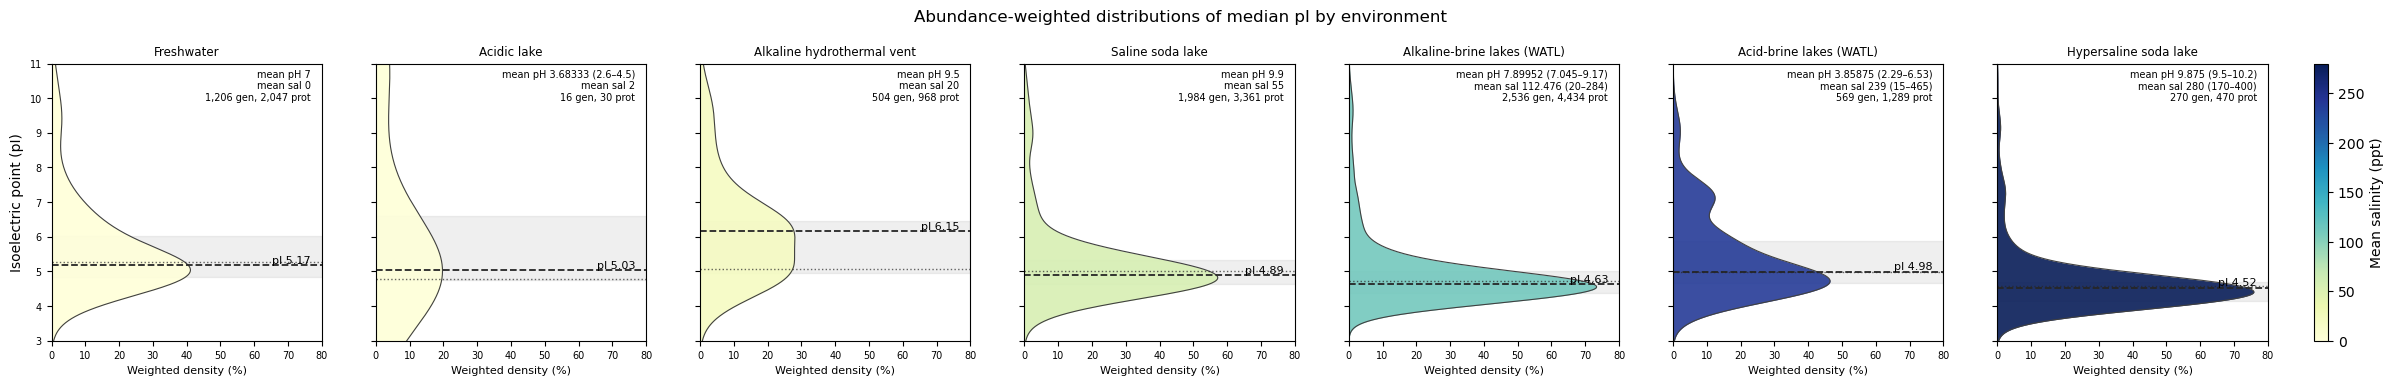

In [21]:

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from scipy.stats import gaussian_kde

Y_MIN, Y_MAX = 3, 11
ORDER_BY = "salinity"        # "salinity" | "pH" | "median_pI"
CMAP_NAME = "YlGnBu"         # sequential salinity colormap
TITLE = "Abundance-weighted distributions of median pI by environment"
PANEL_W = 4.3        # width per environment panel (larger = wider)
FIG_H   = 3.6        # overall figure height (smaller = less tall)
PCT     = 100        # scale KDE density to "Density (%)" (matches original Fig 3C)
XMAX    = 80         # x-axis max (Density %); raise if a peak clips

df = filtered_All_envs_df_with_metadata.copy()
df["Median_pI"] = pd.to_numeric(df["Median_pI"], errors="coerce")
df["Environment_Bin"] = df["Environment_Bin"].astype(str).str.strip()
for c in ("pH", "Salinity"):
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# RPKM weights: coerce, drop non-positive, track which rows are truly weighted, fall back to 1.0
if "rpkm" not in df.columns:
    df["rpkm"] = 1.0
df["rpkm"] = pd.to_numeric(df["rpkm"], errors="coerce")
df.loc[df["rpkm"] <= 0, "rpkm"] = np.nan
df["_rpkm_real"] = df["rpkm"].notna()
df["rpkm"] = df["rpkm"].fillna(1.0)

df = df.dropna(subset=["Median_pI", "Environment_Bin"]).copy()
df = df[df["Environment_Bin"] != "Unclassified"]

#  per-bin stats
def _stat_lakes(g, col):
    # average over the DISTINCT lakes (name_full) in the bin, so merged categories
    # (e.g. Hypersaline soda lake) report the AVERAGE pH/salinity of their lakes
    lk = g.groupby("name_full")[col].first() if "name_full" in g.columns else g[col]
    s = pd.to_numeric(lk, errors="coerce").dropna()
    return (np.nan, np.nan, np.nan) if s.empty else (float(s.mean()), float(s.min()), float(s.max()))

stats = {}
for e, g in df.groupby("Environment_Bin"):
    u = g.drop_duplicates("contig_id") if "contig_id" in g.columns else g
    pH = _stat_lakes(g, "pH"); sal = _stat_lakes(g, "Salinity")
    n_prot = int(pd.to_numeric(u["n_structural"], errors="coerce").fillna(0).sum()) if "n_structural" in u.columns else 0
    stats[e] = dict(pH=pH, sal=sal, frac_w=float(g["_rpkm_real"].mean()),
                    n_gen=(u["contig_id"].nunique() if "contig_id" in u.columns else len(u)), n_prot=n_prot)

# order panels
if ORDER_BY == "salinity":
    env_order = sorted(stats, key=lambda e: (np.inf if np.isnan(stats[e]["sal"][0]) else stats[e]["sal"][0]))
elif ORDER_BY == "pH":
    env_order = sorted(stats, key=lambda e: (np.inf if np.isnan(stats[e]["pH"][0]) else stats[e]["pH"][0]))
else:
    env_order = df.groupby("Environment_Bin")["Median_pI"].median().sort_values().index.tolist()

#  color panels by salinity 
sal_meds = [stats[e]["sal"][0] for e in env_order if not np.isnan(stats[e]["sal"][0])]
norm = Normalize(vmin=min(sal_meds), vmax=max(sal_meds))
cmap = cm.get_cmap(CMAP_NAME)
sm = ScalarMappable(norm=norm, cmap=cmap)
def _color(e):
    s = stats[e]["sal"][0]
    return cmap(0.0) if np.isnan(s) else sm.to_rgba(s)

#  shared weighted-density scale 
x = np.linspace(Y_MIN, Y_MAX, 400)
gmax = 0.0
for e in env_order:
    sub = df[df["Environment_Bin"] == e]
    v, w = sub["Median_pI"].values, sub["rpkm"].values
    if len(v) > 1 and np.std(v) > 0 and w.sum() > 0:
        gmax = max(gmax, float(np.max(gaussian_kde(v, weights=w)(x))) * PCT)
gmax = gmax or 1.0

fig, axes = plt.subplots(1, len(env_order), figsize=(max(PANEL_W * len(env_order), 10), FIG_H), sharey=True)
if len(env_order) == 1:
    axes = [axes]

def _fmt(med, lo, hi):
    if np.isnan(med): return "n/a"
    return f"{med:g}" if (np.isnan(lo) or abs(hi - lo) < 1e-9) else f"{med:g} ({lo:g}\u2013{hi:g})"

for ax, e in zip(axes, env_order):
    st = stats[e]; color = _color(e)
    sub = df[df["Environment_Bin"] == e]
    v, w = sub["Median_pI"].values, sub["rpkm"].values
    if len(v) > 1 and np.std(v) > 0 and w.sum() > 0:
        dens = gaussian_kde(v, weights=w)(x) * PCT
        ax.fill_betweenx(x, 0, dens, color=color, alpha=0.9, linewidth=0)
        ax.plot(dens, x, color="0.25", linewidth=0.8)
    if len(v) > 0:
        med    = wquantile(v, w, 0.50)                    # abundance-weighted median (matches the weighted density)
        q1, q3 = wquantile(v, w, 0.25), wquantile(v, w, 0.75)
        ax.fill_between([0, XMAX], q1, q3, color="0.5", alpha=0.12, zorder=0)   # weighted IQR band
        ax.axhline(med, color="0.15", linestyle="--", linewidth=1.3)                    # weighted median
        ax.axhline(float(np.median(v)), color="0.15", linestyle=":", linewidth=1.0, alpha=0.7)  # unweighted median (dotted)
        ax.text(0.96, med, f"pI {med:.2f}", fontsize=8, va="bottom", ha="right",
                transform=ax.get_yaxis_transform())
    label = (f"mean pH {_fmt(*st['pH'])}\n"
             f"mean sal {_fmt(*st['sal'])}\n"
             f"{st['n_gen']:,} gen, {st['n_prot']:,} prot")
    ax.text(0.96, Y_MAX - (Y_MAX - Y_MIN) * 0.02, label, fontsize=7, ha="right", va="top",
            transform=ax.get_yaxis_transform())
    ax.set_title(e, fontsize=8.5)
    ax.set_ylim(Y_MIN, Y_MAX); ax.set_xlim(0, XMAX)
    ax.set_xlabel("Weighted density (%)", fontsize=8)
    ax.set_ylabel("Isoelectric point (pI)" if ax is axes[0] else "")
    ax.tick_params(labelsize=7)

cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.02, orientation="vertical")
cbar.set_label("Mean salinity (ppt)")
plt.suptitle(TITLE, fontsize=12, y=1.03)
plt.savefig("/Users/skoog/Desktop/weighted_median_pI_kde_by_env.svg", format="svg", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("/Users/skoog/Desktop/weighted_median_pI_kde_by_env.png", format="png", dpi=300, bbox_inches="tight")
plt.show()


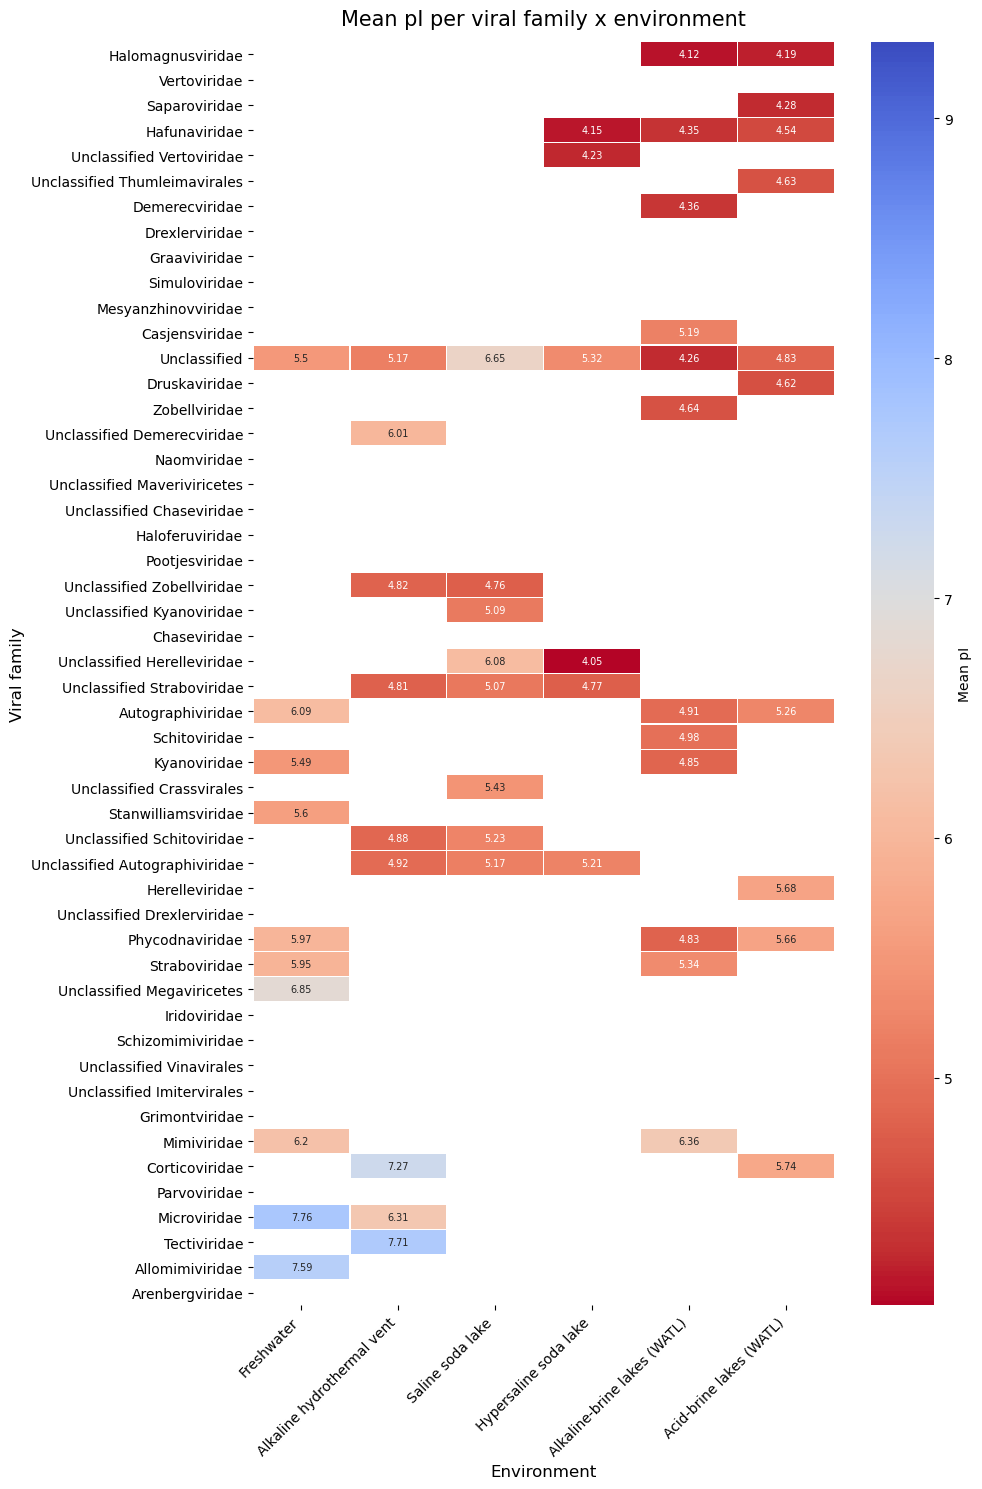

saved /Users/skoog/Desktop/median_pI_family_by_env_heatmap.svg/.png + pivot and per-cell-n CSVs (50 families x 6 environments; 45 cells masked for < 3 genomes)


In [22]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
from matplotlib.colors import TwoSlopeNorm

EXCLUDE_UNCLASSIFIED_CAUDO = True
AGG = "mean"            
MIN_CELL_N = 3          
NEUTRAL_PI = 7
TITLE = "Mean pI per viral family x environment"
OUT_FIG = "/Users/skoog/Desktop/median_pI_family_by_env_heatmap"     # .svg + .png
OUT_CSV = "/Users/skoog/Desktop/Revisions/median_pI_family_by_env_pivot.csv"

PREFERRED_ENV_ORDER = [
    "Freshwater", "Acidic lake", "Alkaline hydrothermal vent",
    "Saline soda lake", "Hypersaline soda lake",
    "Alkaline-brine lakes (WATL)", "Acid-brine lakes (WATL)",
]

df = filtered_All_envs_df_with_metadata.copy()
df["Environment_Bin"] = df["Environment_Bin"].astype(str).str.strip()
df = df.dropna(subset=["Median_pI", "family", "Environment_Bin"]).copy()
df = df[df["Environment_Bin"] != "Unclassified"].copy()
if EXCLUDE_UNCLASSIFIED_CAUDO:
    df = df[df["family"] != "Unclassified Caudoviricetes"].copy()
df = df.drop_duplicates(["contig_id", "Environment_Bin"]).copy()   # one value per genome per env

aggfunc = {"mean": "mean", "median": "median"}[AGG]
pivot = df.groupby(["family", "Environment_Bin"])["Median_pI"].agg(aggfunc).unstack("Environment_Bin")
counts = df.groupby(["family", "Environment_Bin"])["Median_pI"].size().unstack("Environment_Bin")

envs_present = pivot.columns.tolist()
col_order = [e for e in PREFERRED_ENV_ORDER if e in envs_present] + \
            [e for e in envs_present if e not in PREFERRED_ENV_ORDER]
row_order = [f for f in df.groupby("family")["Median_pI"].median().sort_values().index if f in pivot.index]
pivot = pivot.loc[row_order, col_order]
counts = counts.reindex(index=pivot.index, columns=pivot.columns).fillna(0)
pivot.to_csv(OUT_CSV)
counts.to_csv(OUT_CSV.replace("_pivot.csv", "_pivot_n.csv"))

mask = pivot.isna() | (counts < MIN_CELL_N)
n_masked = int(((counts < MIN_CELL_N) & pivot.notna()).sum().sum())

vmin, vmax = float(np.nanmin(pivot.values)), float(np.nanmax(pivot.values))
if np.isclose(vmin, vmax) or not np.isfinite([vmin, vmax]).all():
    vmin, vmax = 6.9, 7.1
norm = TwoSlopeNorm(vmin=min(vmin, NEUTRAL_PI - 1e-3), vcenter=NEUTRAL_PI, vmax=max(vmax, NEUTRAL_PI + 1e-3))

fig_w = max(10, 1.3 * len(col_order)); fig_h = max(5, 0.30 * len(row_order))
plt.figure(figsize=(fig_w, fig_h))
ax = sns.heatmap(pivot, cmap="coolwarm_r", norm=norm, linewidths=0.25, linecolor="white",
                 cbar_kws={"label": f"{AGG.capitalize()} pI"}, square=False,
                 mask=mask, annot=pivot.round(2), fmt="", annot_kws={"size": 7})
ax.set_title(TITLE, fontsize=15, pad=12)
ax.set_xlabel("Environment", fontsize=12); ax.set_ylabel("Viral family", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT_FIG + ".svg", format="svg", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig(OUT_FIG + ".png", format="png", dpi=300, bbox_inches="tight")
plt.show()
print(f"saved {OUT_FIG}.svg/.png + pivot and per-cell-n CSVs "
      f"({pivot.shape[0]} families x {pivot.shape[1]} environments; "
      f"{n_masked} cells masked for < {MIN_CELL_N} genomes)")


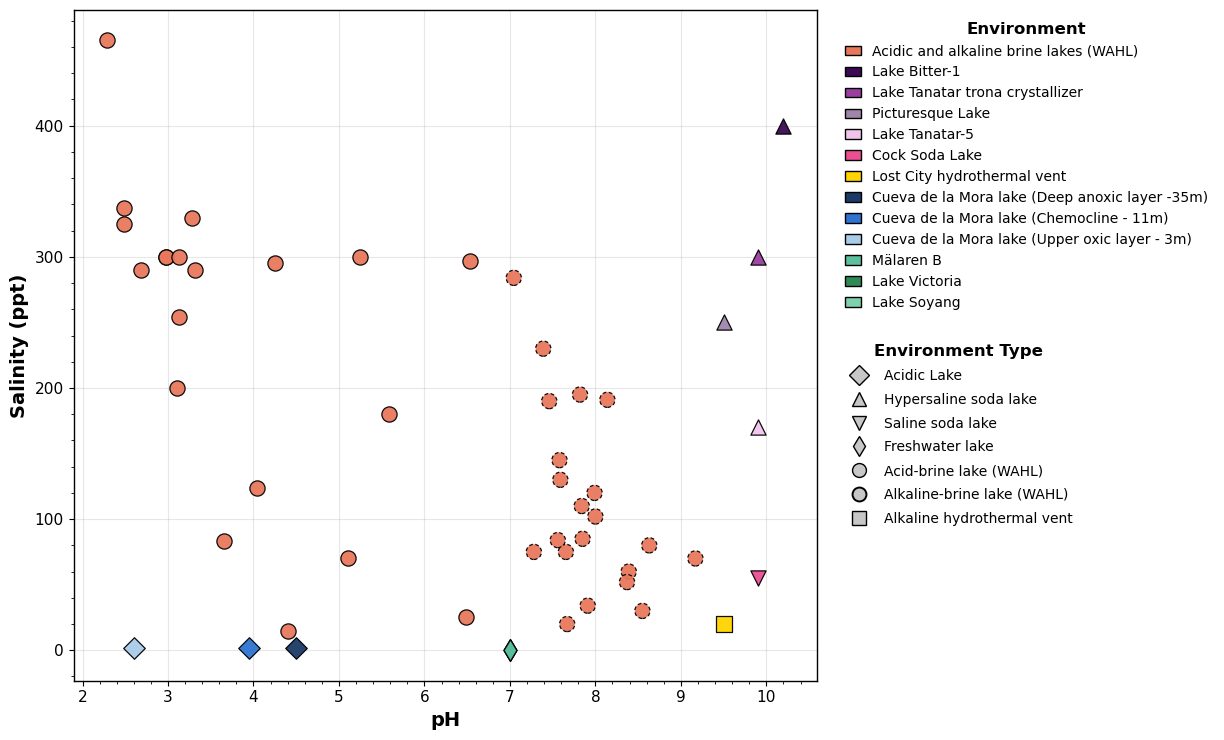


acidic-lake rows in the data: {'Cueva de la Mora lake - Chemocline (11m)': 10, 'Cueva de la Mora lake - Deep Anoxic Layer (35m)': 5, 'Cueva de la Mora lake - Upper Oxic Layer (3m)': 1}

sites plotted:
                                      name_full                                      env_source                   env_type     pH  Salinity
                                  Lake Victoria                                   Lake Victoria                 Freshwater  7.000       0.0
                                      Malaren B                                       Malaren B                 Freshwater  7.000       0.0
                                    Lake Soyang                                     Lake Soyang                 Freshwater  7.000       0.0
       Cueva de la Mora lake - Chemocline (11m)        Cueva de la Mora lake - Chemocline (11m)                Acidic lake  3.950       2.0
Cueva de la Mora lake - Deep Anoxic Layer (35m) Cueva de la Mora lake - Deep Anoxic Layer (35m)   

In [23]:

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
import pandas as pd, numpy as np

SOURCES = [
    ("Acidic and alkaline brine lakes (WAHL)", "Acidic and alkaline brine lakes (WAHL)", "#E8785C"),
    ("Lake Bitter-1",                          "Lake Bitter-1",                          "#3B0A54"),
    ("Lake Tanatar trona crystallizer",        "Lake Tanatar trona crystallizer",        "#9B3F9E"),
    ("Picturesque Lake",                       "Picturesque Lake",                       "#9E86AB"),
    ("Lake Tanatar-5",                         "Lake Tanatar-5",                         "#F2C4EC"),
    ("Cock Soda Lake",                         "Cock Soda Lake",                         "#EC4E92"),
    ("Lost City",                              "Lost City hydrothermal vent",            "#FFD400"),
    ("Cueva de la Mora lake - Deep Anoxic Layer (35m)", "Cueva de la Mora lake (Deep anoxic layer -35m)", "#1B3A66"),
    ("Cueva de la Mora lake - Chemocline (11m)",        "Cueva de la Mora lake (Chemocline - 11m)",       "#2E74D0"),
    ("Cueva de la Mora lake - Upper Oxic Layer (3m)",   "Cueva de la Mora lake (Upper oxic layer - 3m)",  "#A9CCE8"),
    ("Malaren B",                              "M\u00e4laren B",                          "#5CBF9E"),
    ("Lake Victoria",                          "Lake Victoria",                          "#2E8B57"),
    ("Lake Soyang",                            "Lake Soyang",                            "#7FD1AE"),
]

MARKER_MAP = {
    "Acidic Lake": "D", "Hypersaline soda lake": "^", "Saline soda lake": "v",
    "Freshwater lake": "d", "Freshwater": "d",
    "Acid-brine lake (WAHL)": "o", "Alkaline-brine lake (WAHL)": "o",
    "Alkaline hydrothermal vent": "s",
}
TYPE_ORDER = ["Acidic Lake", "Hypersaline soda lake", "Saline soda lake", "Freshwater lake",
              "Acid-brine lake (WAHL)", "Alkaline-brine lake (WAHL)", "Alkaline hydrothermal vent"]
DASHED_EDGE_TYPES = {"Alkaline-brine lake (WAHL)"}
DASH_STYLE = (0, (3, 2))

def _norm(s): return str(s).strip().casefold()
_COLOR_N  = {_norm(k): c   for k, _, c in SOURCES}
_LABEL_N  = {_norm(k): lab for k, lab, _ in SOURCES}
_MARKER_N = {_norm(k): v   for k, v in MARKER_MAP.items()}

site = filtered_All_envs_df_with_metadata.dropna(subset=["pH", "Salinity"]).copy()
site = site[site.get("Environment_Bin", "").astype(str).str.strip() != "Unclassified"]

def is_watl(r):
    binn = str(r.get("Environment_Bin", ""))
    return str(r.get("Environment", "")).startswith("WATL") or "WATL" in binn or "WAHL" in binn
def is_fresh(r):
    return str(r.get("Environment_Bin", "")).strip() == "Freshwater"
def resolve_source(r):
    if is_watl(r):  return "Acidic and alkaline brine lakes (WAHL)"
    return r.get("name_full")          # comparator lakes AND the 3 freshwater lakes keep identity
def resolve_type(r):
    if is_watl(r):
        pH = r.get("pH")
        if pd.isna(pH): return None
        return "Acid-brine lake (WAHL)" if pH < 7 else "Alkaline-brine lake (WAHL)"
    return r.get("Environment_Type")

site["env_source"] = site.apply(resolve_source, axis=1)
site["env_type"]   = site.apply(resolve_type,  axis=1)
site = (site.groupby("name_full")
        .agg(pH=("pH", "first"), Salinity=("Salinity", "first"),
             env_source=("env_source", "first"), env_type=("env_type", "first")).reset_index())

miss_c = sorted({s for s in site["env_source"].dropna().unique() if _norm(s) not in _COLOR_N})
miss_m = sorted({t for t in site["env_type"].dropna().unique()   if _norm(t) not in _MARKER_N})
if miss_c: print("!! name_full with NO colour (grey) -- add to SOURCES:", miss_c)
if miss_m: print("!! Environment_Type with NO marker ('o') -- add to MARKER_MAP:", miss_m)

def color_of(s):  return _COLOR_N.get(_norm(s), "#BEBEBE")
def marker_of(t): return _MARKER_N.get(_norm(t), "o")

fig, ax = plt.subplots(figsize=(11, 7.5))
for (src, typ), s in site.groupby(["env_source", "env_type"], dropna=False):
    pc = ax.scatter(s["pH"], s["Salinity"], facecolor=color_of(src), marker=marker_of(typ),
                    edgecolor="black", s=120, alpha=0.95, linewidth=0.9, zorder=3)
    if typ in DASHED_EDGE_TYPES:
        pc.set_linestyle(DASH_STYLE)

present = {_norm(x) for x in site["env_source"].dropna().unique()}
env_handles = [Patch(facecolor=c, edgecolor="black", label=lab)
               for k, lab, c in SOURCES if _norm(k) in present]
leg1 = ax.legend(handles=env_handles, title="Environment", bbox_to_anchor=(1.02, 1.0),
                 loc="upper left", frameon=False, handlelength=1.2, labelspacing=0.5, fontsize=10)
leg1.get_title().set_fontsize(12); leg1.get_title().set_fontweight("bold")
ax.add_artist(leg1)

TYPE_LEGEND = [
    (["Acidic lake", "Acidic Lake"],      "Acidic Lake",                 "D", False),
    (["Hypersaline soda lake"],           "Hypersaline soda lake",       "^", False),
    (["Saline soda lake"],                "Saline soda lake",            "v", False),
    (["Freshwater", "Freshwater lake"],   "Freshwater lake",             "d", False),
    (["Acid-brine lake (WAHL)"],          "Acid-brine lake (WAHL)",      "o", False),
    (["Alkaline-brine lake (WAHL)"],      "Alkaline-brine lake (WAHL)",  "o", True),
    (["Alkaline hydrothermal vent"],      "Alkaline hydrothermal vent",  "s", False),
]
present_t = {_norm(x) for x in site["env_type"].dropna().unique()}
type_handles = [Line2D([], [], marker=mk, linestyle="None", markersize=10,
                       markerfacecolor="#C7C7C7", markeredgecolor="black",
                       markeredgewidth=(1.4 if dashed else 1.0), label=lab)
                for keys, lab, mk, dashed in TYPE_LEGEND
                if any(_norm(k) in present_t for k in keys)]
leg2 = ax.legend(handles=type_handles, title="Environment Type", bbox_to_anchor=(1.02, 0.52),
                 loc="upper left", frameon=False, labelspacing=0.7, fontsize=10)
leg2.get_title().set_fontsize(12); leg2.get_title().set_fontweight("bold")

ax.set_xlabel("pH", fontsize=14, fontweight="bold")
ax.set_ylabel("Salinity (ppt)", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
for sp in ax.spines.values(): sp.set_linewidth(1); sp.set_edgecolor("black")
ax.minorticks_on()
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.savefig("/Users/skoog/Desktop/site_pH_salinity_by_category.svg", format="svg", dpi=300, bbox_inches="tight", transparent=True)
plt.savefig("/Users/skoog/Desktop/site_pH_salinity_by_category.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

_raw = filtered_All_envs_df_with_metadata.copy()
_raw["Environment_Bin"] = _raw["Environment_Bin"].astype(str).str.strip()
_raw = _raw[_raw["Environment_Bin"] != "Unclassified"]
_lost = sorted(_raw[_raw["pH"].isna() | _raw["Salinity"].isna()]["name_full"].dropna().unique())
if _lost:
    print("!! dropped for missing pH/Salinity (fix these in your metadata to plot them):", _lost)
_acidic = _raw[_raw["Environment_Bin"].str.contains("Acidic", case=False, na=False)]
print("\nacidic-lake rows in the data:",
      _acidic.groupby("name_full").size().to_dict() or "NONE -- filtered out upstream")
print("\nsites plotted:")
print(site[["name_full", "env_source", "env_type", "pH", "Salinity"]]
      .sort_values("Salinity").to_string(index=False))

print(f"\n{len(site)} sites | {len(env_handles)} Environment colours, {len(type_handles)} Environment-Type shapes")


In [24]:

import pandas as pd

_t = filtered_All_envs_df_with_metadata.dropna(subset=["Median_pI"]).copy()
_t = _t[_t["Environment_Bin"] != "Unclassified"].drop_duplicates(["contig_id", "Environment_Bin"])

fam = (_t.groupby(["realm", "order", "family"], dropna=False)
       .agg(n_genomes=("contig_id", "nunique"), median_pI=("Median_pI", "median"))
       .reset_index().sort_values("n_genomes", ascending=False))
env_map = (_t.groupby("family")["name_full"]
           .agg(lambda s: ", ".join(sorted(set(s.astype(str))))).rename("environments"))
fam = fam.merge(env_map, on="family", how="left")
fam["median_pI"] = fam["median_pI"].round(2)

print(f"{fam['family'].nunique()} unique families | {_t['order'].nunique()} orders | {_t['realm'].nunique()} realms")
display(fam)
fam.to_csv("/Users/skoog/Desktop/Revisions/virus_taxa_in_analysis.csv", index=False)
print("wrote virus_taxa_in_analysis.csv  (family-level; also see 'order'/'realm' columns)")

# orders too, in case you'd rather cull at order level
order_tbl = (_t.groupby(["realm", "order"], dropna=False)
             .agg(n_genomes=("contig_id", "nunique"), median_pI=("Median_pI", "median"))
             .reset_index().sort_values("n_genomes", ascending=False))
order_tbl["median_pI"] = order_tbl["median_pI"].round(2)
display(order_tbl)


51 unique families | 25 orders | 4 realms


,realm,order,family,n_genomes,median_pI,environments
0,Duplodnaviria,Unclassified Caudoviricetes,Unclassified Caudoviricetes,6376,4.94,"Anderson Lake, Balicup Lake, Bullfinch complex East, Bullfinch complex West, Camel Lake, Cock Soda Lake, Coramup Creek, Cranbrook Pink Lake, Crusty Lake, Cueva de la Mora lake - Chemocline (11m), Cueva de la Mora lake - Deep Anoxic Layer (35m), Cueva de la Mora lake - Upper Oxic Layer (3m), Doodlakine complex, Gastropod Lake East, Gastropod Lake West, Hobby Lake, Jebarjup Swan Lake, Lake Bitter-1, Lake Brown, Lake Campion, Lake Campion complex North, Lake Campion complex South, Lake Clifton, Lake Dundas North, Lake Gore, Lake Gounter, Lake Gounter 3A, Lake Gounter 3B, Lake Koorkoordine, Lake Koorkoordine (pond across road), Lake Soyang, Lake Tanatar trona crystallizer, Lake Tanatar-5, Lake Victoria, Lake Warden, Lost City, Malaren B, No Name Lake, Picturesque Lake, Pink Lake, Pink Lake , Racecourse Lake, Red Lake, Sunrise Hill, Sunrise Hill Lake, Tom South Lake, Twin Lake East, Twin Lake West, Twin Lake West 7B, Weird Veg Lake, White Sands Lake (lake water), Yellow Lake, Yellowdine Lake"
1,Duplodnaviria,Unclassified Caudoviricetes,Kyanoviridae,153,4.99,"Anderson Lake, Balicup Lake, Camel Lake, Gastropod Lake East, Jebarjup Swan Lake, Lake Clifton, Lake Dundas North, Lake Gore, Lake Gounter, Lake Soyang, Lake Victoria, Lake Warden, Malaren B, Pink Lake, Racecourse Lake, Tom South Lake, White Sands Lake (lake water)"
2,Duplodnaviria,Unclassified Caudoviricetes,Autographiviridae,42,4.94,"Balicup Lake, Bullfinch complex East, Camel Lake, Coramup Creek, Gastropod Lake East, Jebarjup Swan Lake, Lake Campion, Lake Clifton, Lake Dundas North, Lake Gore, Lake Gounter, Lake Warden, Malaren B, Pink Lake, Pink Lake , Tom South Lake, Weird Veg Lake"
3,NaN,Unclassified,Unclassified,31,4.42,"Bullfinch complex East, Camel Lake, Cock Soda Lake, Gastropod Lake East, Gastropod Lake West, Lake Brown, Lake Campion complex South, Lake Gore, Lake Koorkoordine, Lake Soyang, Lake Tanatar trona crystallizer, Lake Tanatar-5, Lake Victoria, Lost City, Picturesque Lake, Weird Veg Lake"
4,Duplodnaviria,Autographiviridae,Unclassified Autographiviridae,29,5.14,"Cock Soda Lake, Lake Tanatar-5, Lost City"
5,Varidnaviria,Algavirales,Phycodnaviridae,28,5.31,"Camel Lake, Cock Soda Lake, Doodlakine complex, Lake Koorkoordine (pond across road), Lake Soyang, Lake Tanatar-5, Lost City, Malaren B, Tom South Lake, Yellow Lake"
6,Duplodnaviria,Thumleimavirales,Halomagnusviridae,26,4.13,"Balicup Lake, Cranbrook Pink Lake, Gastropod Lake West, Lake Brown, Lake Campion, Lake Gounter, Lake Koorkoordine, Lake Warden, Twin Lake West"
7,Duplodnaviria,Unclassified Caudoviricetes,Stanwilliamsviridae,23,5.03,"Lake Soyang, Malaren B"
8,Duplodnaviria,Straboviridae,Unclassified Straboviridae,20,4.92,"Cock Soda Lake, Lake Tanatar-5, Lost City"
9,Duplodnaviria,Thumleimavirales,Hafunaviridae,18,4.17,"Anderson Lake, Lake Bitter-1, Lake Campion, Lake Gounter, Lake Koorkoordine, Lake Tanatar trona crystallizer, Lake Warden, Picturesque Lake, Pink Lake, Twin Lake West"


wrote virus_taxa_in_analysis.csv  (family-level; also see 'order'/'realm' columns)


,realm,order,n_genomes,median_pI
12,Duplodnaviria,Unclassified Caudoviricetes,6660,4.94
11,Duplodnaviria,Thumleimavirales,51,4.17
25,NaN,Unclassified,31,4.42
1,Duplodnaviria,Autographiviridae,29,5.14
17,Varidnaviria,Algavirales,28,5.31
19,Varidnaviria,Imitervirales,23,6.02
10,Duplodnaviria,Straboviridae,20,4.92
15,Monodnaviria,Petitvirales,18,6.32
6,Duplodnaviria,Herelleviridae,17,4.92
9,Duplodnaviria,Schitoviridae,17,5.13


In [41]:

import numpy as np, pandas as pd
from scipy.stats import kruskal

N_BOOT      = 1000
MIN_GROUP_N = 30        # groups smaller than this are excluded from the OMNIBUS
                        # (kept descriptively): Acidic lake (n~14) cannot be powered.
SEED        = 0
OUT_CSV     = "/Users/skoog/Desktop/Revisions/env_pI_descriptive_and_omnibus.csv"


try:
    wquantile
except NameError:
    def wquantile(v, w, q):
        v = np.asarray(v, float); w = np.asarray(w, float)
        m = np.isfinite(v) & np.isfinite(w) & (w > 0)
        v, w = v[m], w[m]
        if v.size == 0: return np.nan
        o = np.argsort(v); v, w = v[o], w[o]
        cw = np.cumsum(w) - 0.5 * w
        cw /= w.sum()
        return float(np.interp(q, cw, v))

# one pI per genome per environment 
d = filtered_All_envs_df_with_metadata.copy()
d["Median_pI"] = pd.to_numeric(d["Median_pI"], errors="coerce")
d["Environment_Bin"] = d["Environment_Bin"].astype(str).str.strip()
if "rpkm" not in d.columns:
    d["rpkm"] = 1.0
d["rpkm"] = pd.to_numeric(d["rpkm"], errors="coerce")
d.loc[d["rpkm"] <= 0, "rpkm"] = np.nan
d = d[(d["Environment_Bin"] != "Unclassified") & d["Median_pI"].notna()]

# genome-level RPKM = sum of per-sample RPKM for that contig in that environment (so the WATL long/per-sample rows collapse to ONE weighted genome observation)
key = ["contig_id", "Environment_Bin"]
gsum = (d.groupby(key, as_index=False)
          .agg(Median_pI=("Median_pI", "first"),
               rpkm=("rpkm", "sum")))
gsum["rpkm"] = gsum["rpkm"].fillna(0.0)
gsum.loc[gsum["rpkm"] <= 0, "rpkm"] = np.nan   # no real weight -> unweighted fallback below

groups   = {e: g["Median_pI"].to_numpy() for e, g in gsum.groupby("Environment_Bin")}
weights  = {e: g["rpkm"].to_numpy()      for e, g in gsum.groupby("Environment_Bin")}
sizes    = {e: len(v) for e, v in groups.items()}

#  weighted and unweighted medians
rows = []
for e in sorted(sizes, key=lambda x: -sizes[x]):
    v = groups[e]; w = weights[e]
    w_ok = np.isfinite(w) & (w > 0)
    ww = w if w_ok.any() else np.ones_like(v)   # fall back to unweighted if no RPKM
    rows.append(dict(
        environment=e, n_genomes=sizes[e],
        median_pI_weighted=round(wquantile(v, ww, 0.50), 3),
        q1_weighted=round(wquantile(v, ww, 0.25), 3),
        q3_weighted=round(wquantile(v, ww, 0.75), 3),
        median_pI_unweighted=round(float(np.median(v)), 3),
        pct_rpkm_weighted=round(100 * w_ok.mean(), 1),
    ))
desc = pd.DataFrame(rows)
print("PER-ENVIRONMENT DESCRIPTIVE pI  (copy medians into the text):")
print(desc.to_string(index=False))

#  raw KW 
allv = list(groups.values())
H0, p0 = kruskal(*allv)
n_all, k_all = sum(sizes.values()), len(groups)
#eps0 = (H0 - k_all + 1) / (n_all - k_all)
#es[b] = (H - k + 1) / (target_n * k - k)      # →  es[b] = H / (target_n * k - 1)
eps0 = H0 / (n_all - 1)
print(f"\nRAW KW (unbalanced, reported only as the inflated reference): "
      f"H={H0:.1f}, p={p0:.1e}, eps^2={eps0:.4f}, k={k_all}")

#balanced omnibus
retained = [e for e in groups if sizes[e] >= MIN_GROUP_N]
excluded = [e for e in groups if sizes[e] <  MIN_GROUP_N]
k = len(retained)
n_min = min(sizes[e] for e in retained)
n_med = int(round(np.median([sizes[e] for e in retained])))
print(f"\nomnibus groups (n>={MIN_GROUP_N}): {retained}")
if excluded:
    print(f"excluded from omnibus (too small, kept descriptively): "
          f"{[(e, sizes[e]) for e in excluded]}")

def balanced_kw(target_n, seed=SEED):
    rng = np.random.default_rng(seed)
    Hs = np.empty(N_BOOT); ps = np.empty(N_BOOT); es = np.empty(N_BOOT)
    for b in range(N_BOOT):
        samp = []
        for e in retained:
            v = groups[e]
            replace = target_n > len(v)          # only up-sample when unavoidable
            samp.append(rng.choice(v, size=target_n, replace=replace))
        H, p = kruskal(*samp)
        Hs[b], ps[b] = H, p
        es[b] = H / (target_n * k - 1)
        #es[b] = (H - k + 1) / (target_n * k - k)
    ci = lambda a: (np.percentile(a, 2.5), np.median(a), np.percentile(a, 97.5))
    return Hs, ps, es, ci

for label, tn in [("min-of-retained (headline, no up-sampling)", n_min),
                  ("median-of-retained (sensitivity)",           n_med)]:
    Hs, ps, es, ci = balanced_kw(tn)
    hl, hm, hh = ci(Hs); el, em, eh = ci(es)
    print(f"\nBALANCED KW  [{label}]  n={tn}/group x {N_BOOT} boot, {k} groups:")
    print(f"  H        median={hm:7.1f}   95% CI [{hl:.1f}, {hh:.1f}]")
    print(f"  p        median={np.median(ps):.2e}   frac p<0.05={np.mean(ps<0.05):.3f}")
    print(f"  eps^2    median={em:.4f}   95% CI [{el:.4f}, {eh:.4f}]"
          f"   (rank-based: ~0.01 small / 0.08 medium / 0.26 large)")

desc.to_csv(OUT_CSV, index=False)
print(f"\nwrote {OUT_CSV}")


PER-ENVIRONMENT DESCRIPTIVE pI  (copy medians into the text):
                environment  n_genomes  median_pI_weighted  q1_weighted  q3_weighted  median_pI_unweighted  pct_rpkm_weighted
Alkaline-brine lakes (WATL)       2536               4.626        4.379        4.999                 4.767              100.0
           Saline soda lake       1984               4.895        4.624        5.322                 5.021               99.8
                 Freshwater       1206               5.173        4.835        6.021                 5.258              100.0
    Acid-brine lakes (WATL)        569               4.984        4.655        5.877                 4.938              100.0
 Alkaline hydrothermal vent        504               6.155        4.967        6.457                 5.074               98.6
      Hypersaline soda lake        270               4.522        4.151        4.706                 4.586              100.0
                Acidic lake         16               5.0

PAIRWISE pI (sorted by |Cliff's delta|; low_confidence = involves a group n<30):
                    group_1                     group_2   n1   n2  median_pI_diff  cliffs_delta  magnitude        q_fdr  low_confidence
      Hypersaline soda lake                  Freshwater  270 1206           -0.67        -0.501      large 5.093462e-23           False
      Hypersaline soda lake  Alkaline hydrothermal vent  270  504           -0.49        -0.413     medium 5.653491e-16           False
Alkaline-brine lakes (WATL)                  Freshwater 2536 1206           -0.49        -0.389     medium 5.030733e-60           False
      Hypersaline soda lake            Saline soda lake  270 1984           -0.43        -0.366     medium 6.737599e-13           False
      Hypersaline soda lake                 Acidic lake  270   16           -0.20        -0.362     medium 1.133274e-01            True
      Hypersaline soda lake     Acid-brine lakes (WATL)  270  569           -0.35        -0.291      sm

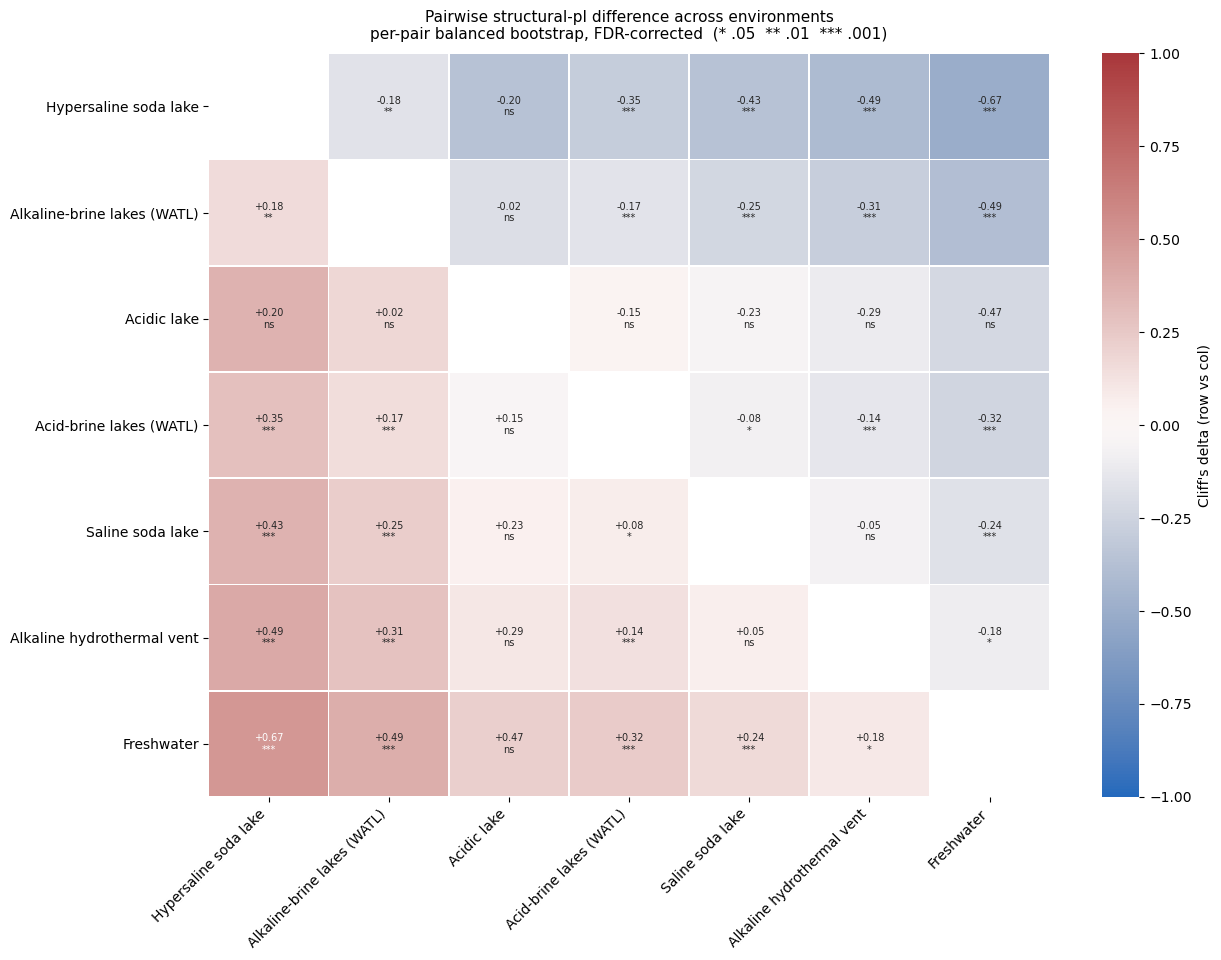

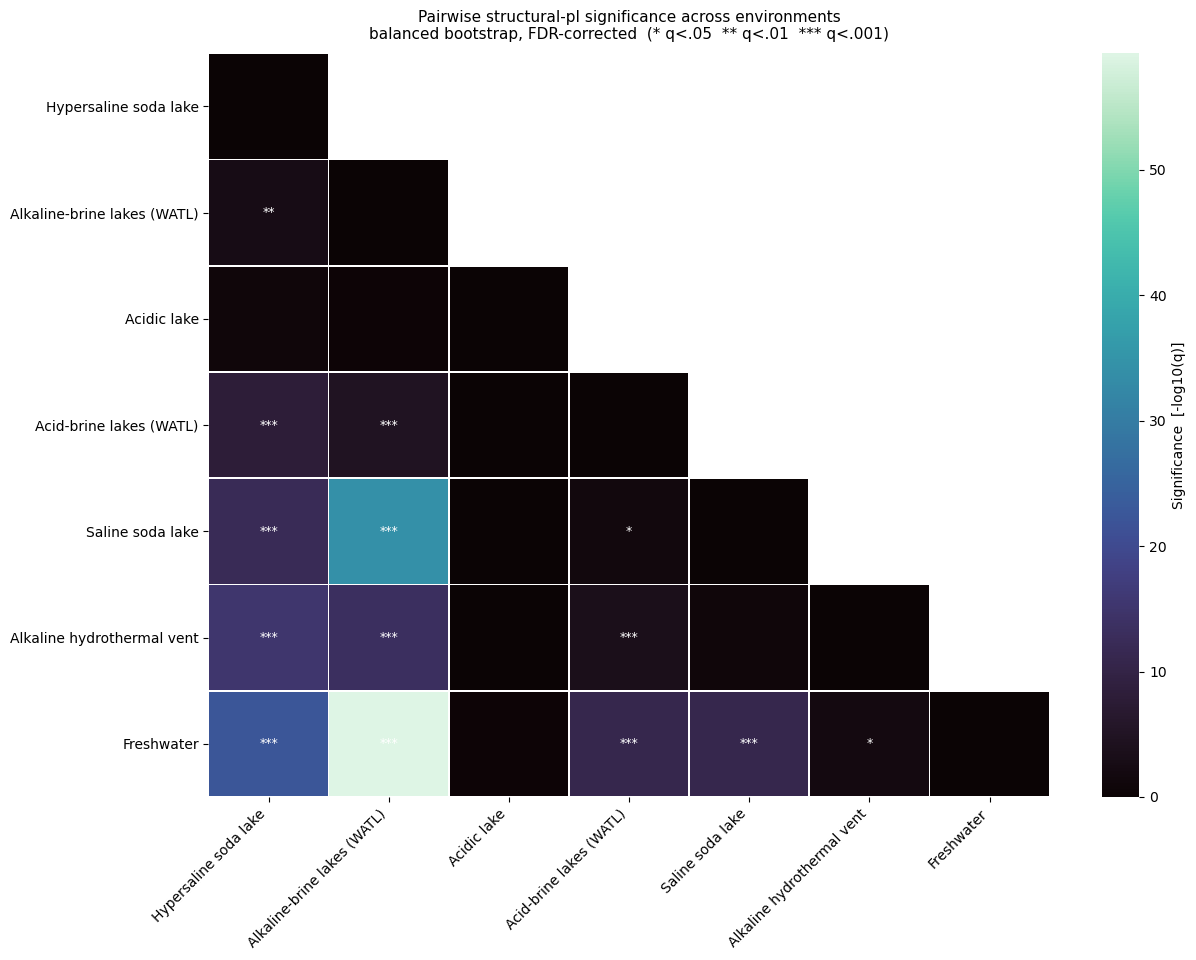


panel D: 7 environments, 14/21 pairs FDR<0.05; max -log10(q)=59; 6 pair(s) flagged low-confidence (small group).


In [42]:

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import mannwhitneyu
from itertools import combinations

N_BOOT      = 1000
MIN_GROUP_N = 30            # same threshold as the omnibus cell
ORDER_BY    = "median_pI"   # "median_pI" | "salinity"
SEED        = 0
OUT_PREFIX  = "/Users/skoog/Desktop/panelD_pairwise_pI"   # .svg/.png/.csv

d = filtered_All_envs_df_with_metadata.copy()
d["Median_pI"] = pd.to_numeric(d["Median_pI"], errors="coerce")
d["Environment_Bin"] = d["Environment_Bin"].astype(str).str.strip()
d = d[(d["Environment_Bin"] != "Unclassified") & d["Median_pI"].notna()]
g1 = d.drop_duplicates(["contig_id", "Environment_Bin"])
groups = {e: sub["Median_pI"].to_numpy() for e, sub in g1.groupby("Environment_Bin")}
sizes  = {e: len(v) for e, v in groups.items()}
small  = {e for e in sizes if sizes[e] < MIN_GROUP_N}

if ORDER_BY == "salinity" and "Salinity" in g1.columns and "name_full" in g1.columns:
    sal = (g1.groupby("Environment_Bin")
             .apply(lambda x: x.groupby("name_full")["Salinity"].first().mean()))
    envs = sal.sort_values().index.tolist()
else:
    envs = (g1.groupby("Environment_Bin")["Median_pI"].median()
              .sort_values().index.tolist())

def cliffs(a, b):
    U, _ = mannwhitneyu(a, b, alternative="two-sided")
    return 2.0 * U / (len(a) * len(b)) - 1.0

def bh(p):                       # Benjamini-Hochberg FDR
    p = np.asarray(p, float); n = len(p); o = np.argsort(p)
    adj = np.minimum.accumulate((p[o] * n / np.arange(1, n + 1))[::-1])[::-1]
    out = np.empty(n); out[o] = np.clip(adj, 0, 1); return out

rng = np.random.default_rng(SEED)
delta = pd.DataFrame(np.nan, index=envs, columns=envs)
diff  = pd.DataFrame(np.nan, index=envs, columns=envs)
pairs, raw_p, flags = list(combinations(envs, 2)), [], []
for a, b in pairs:
    A, B = groups[a], groups[b]
    tn = min(len(A), len(B))                    # per-pair balanced n, no up-sampling
    ps = np.empty(N_BOOT)
    for i in range(N_BOOT):
        sa = rng.choice(A, tn, replace=(tn > len(A)))
        sb = rng.choice(B, tn, replace=(tn > len(B)))
        ps[i] = mannwhitneyu(sa, sb, alternative="two-sided")[1]
    dd, md = cliffs(A, B), float(np.median(A) - np.median(B))
    delta.loc[a, b], delta.loc[b, a] = dd, -dd
    diff.loc[a, b],  diff.loc[b, a]  = md, -md
    raw_p.append(float(np.median(ps)))
    flags.append((a in small) or (b in small))

padj = dict(zip(pairs, bh(raw_p)))
def stars(p): return "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"

def _mag(x):
    a = abs(x)
    return "negligible" if a < .147 else "small" if a < .33 else "medium" if a < .474 else "large"
tab = pd.DataFrame({
    "group_1": [a for a, b in pairs], "group_2": [b for a, b in pairs],
    "n1": [sizes[a] for a, b in pairs], "n2": [sizes[b] for a, b in pairs],
    "median_pI_diff": [round(diff.loc[a, b], 2) for a, b in pairs],
    "cliffs_delta":   [round(delta.loc[a, b], 3) for a, b in pairs],
    "magnitude":      [_mag(delta.loc[a, b]) for a, b in pairs],
    "q_fdr":          [padj[(a, b)] for a, b in pairs],
    "low_confidence": flags,
}).reindex(pd.Series([abs(delta.loc[a, b]) for a, b in pairs]).sort_values(ascending=False).index)
print("PAIRWISE pI (sorted by |Cliff's delta|; low_confidence = involves a group n<%d):" % MIN_GROUP_N)
print(tab.to_string(index=False))
tab.to_csv(OUT_PREFIX + ".csv", index=False)

# Cliff's-delta heatmap
annot = pd.DataFrame("", index=envs, columns=envs)
for a, b in pairs:
    s = stars(padj[(a, b)])
    annot.loc[a, b] = f"{diff.loc[a,b]:+.2f}\n{s}"
    annot.loc[b, a] = f"{diff.loc[b,a]:+.2f}\n{s}"
plt.figure(figsize=(1.4 * len(envs) + 3, 1.1 * len(envs) + 2))
ax = sns.heatmap(delta.astype(float), cmap="vlag", center=0, vmin=-1, vmax=1,
                 linewidths=.5, linecolor="white", mask=delta.isna(),
                 annot=annot.values, fmt="", annot_kws={"size": 7},
                 cbar_kws={"label": "Cliff's delta (row vs col)"})
ax.set_title("Pairwise structural-pI difference across environments\n"
             f"per-pair balanced bootstrap, FDR-corrected  (* .05  ** .01  *** .001)",
             fontsize=11, pad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT_PREFIX + "_cliffs.svg", bbox_inches="tight", transparent=True)
plt.savefig(OUT_PREFIX + "_cliffs.png", dpi=300, bbox_inches="tight")
plt.show()

# -log10(q) significance heatmap
qmat = pd.DataFrame(1.0, index=envs, columns=envs)
for (a, b), q in padj.items():
    qmat.loc[a, b] = q; qmat.loc[b, a] = q
neglogq = -np.log10(qmat.clip(lower=1e-300))
mask = np.triu(np.ones(neglogq.shape, dtype=bool), k=1)
sig = pd.DataFrame("", index=envs, columns=envs)
for (a, b), q in padj.items():
    st = "***" if q < .001 else "**" if q < .01 else "*" if q < .05 else ""
    sig.loc[a, b] = st; sig.loc[b, a] = st
plt.figure(figsize=(1.4 * len(envs) + 3, 1.1 * len(envs) + 2))
ax = sns.heatmap(neglogq.astype(float), cmap="mako", mask=mask | neglogq.isna(),
                 linewidths=.5, linecolor="white", annot=sig.values, fmt="",
                 annot_kws={"size": 9, "color": "white"},
                 cbar_kws={"label": "Significance  [-log10(q)]"})
ax.set_title("Pairwise structural-pI significance across environments\n"
             "balanced bootstrap, FDR-corrected  (* q<.05  ** q<.01  *** q<.001)",
             fontsize=11, pad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT_PREFIX + "_neglogq.svg", bbox_inches="tight", transparent=True)
plt.savefig(OUT_PREFIX + "_neglogq.png", dpi=300, bbox_inches="tight")
plt.show()

n_sig = sum(padj[(a, b)] < 0.05 for a, b in pairs)
print(f"\npanel D: {len(envs)} environments, {n_sig}/{len(pairs)} pairs FDR<0.05; "
      f"max -log10(q)={np.nanmax(neglogq.values):.0f}; "
      f"{sum(flags)} pair(s) flagged low-confidence (small group).")


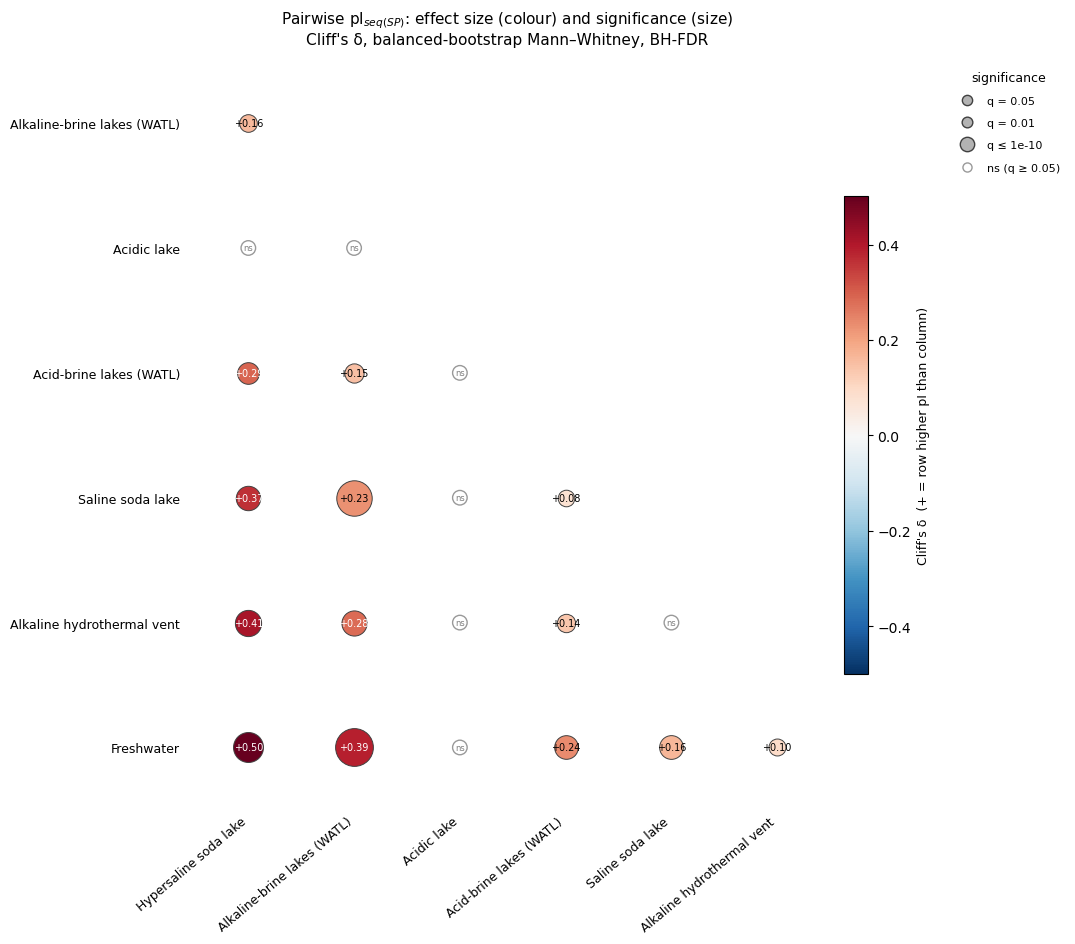

In [43]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
import matplotlib.cm as cm

assert "delta" in dir() and "padj" in dir() and "envs" in dir(), \
    "Run the canonical pairwise cell (cell 26) first — it defines delta, padj, envs."

ORDER = envs                       
n = len(ORDER)
vmax = max(0.3, float(np.nanmax(np.abs(delta.values))))     
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
cmap = plt.get_cmap("RdBu_r")

def q_of(a, b):
    return padj.get((a, b), padj.get((b, a), np.nan))

fig, ax = plt.subplots(figsize=(1.15 * n + 3, 1.15 * n + 1.5))
SIZE_CAP = 40.0                    
handles_drawn = False
for i, row in enumerate(ORDER):         
    for j, col in enumerate(ORDER):
        if j >= i:                       
            continue
        d = delta.loc[row, col]
        q = q_of(row, col)
        nlq = -np.log10(q) if (q and q > 0) else 0.0
        sig = (q is not None) and (q < 0.05)
        if sig:
            size = 120 + 620 * min(nlq, SIZE_CAP) / SIZE_CAP
            ax.scatter(j, i, s=size, color=cmap(norm(d)), edgecolor="0.25",
                       linewidth=0.7, zorder=3)
            ax.text(j, i, f"{d:+.2f}", ha="center", va="center", fontsize=7,
                    color="black" if abs(norm(d)-0.5) < 0.28 else "white", zorder=4)
        else:                            
            ax.scatter(j, i, s=110, facecolor="none", edgecolor="0.6",
                       linewidth=1.0, zorder=3)
            ax.text(j, i, "ns", ha="center", va="center", fontsize=6, color="0.5", zorder=4)

ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(ORDER, rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(ORDER, fontsize=9)
ax.set_xlim(-0.6, n - 1.5); ax.set_ylim(n - 0.5, 0.5)  
ax.set_frame_on(False); ax.tick_params(length=0)
ax.set_title("Pairwise pI$_{seq(SP)}$: effect size (colour) and significance (size)\n"
             "Cliff's \u03b4, balanced-bootstrap Mann\u2013Whitney, BH-FDR",
             fontsize=11, pad=12)

# colour bar
sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
cb.set_label("Cliff's \u03b4  (+ = row higher pI than column)", fontsize=9)

# size legend = significance
leg_q = [(0.05, "q = 0.05"), (0.01, "q = 0.01"), (1e-10, "q \u2264 1e-10")]
handles = []
for qval, lab in leg_q:
    nlq = -np.log10(qval); s = 120 + 620 * min(nlq, SIZE_CAP) / SIZE_CAP
    handles.append(Line2D([], [], marker="o", linestyle="none", markersize=np.sqrt(s)/1.6,
                          markerfacecolor="0.7", markeredgecolor="0.25", label=lab))
handles.append(Line2D([], [], marker="o", linestyle="none", markersize=np.sqrt(110)/1.6,
                      markerfacecolor="none", markeredgecolor="0.6", label="ns (q \u2265 0.05)"))
ax.legend(handles=handles, title="significance", loc="upper left",
          bbox_to_anchor=(1.18, 1.0), frameon=False, labelspacing=1.1, fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig("/Users/skoog/Desktop/panelD_merged.svg", bbox_inches="tight", transparent=True)
plt.savefig("/Users/skoog/Desktop/panelD_merged.png", dpi=300, bbox_inches="tight")
plt.show()


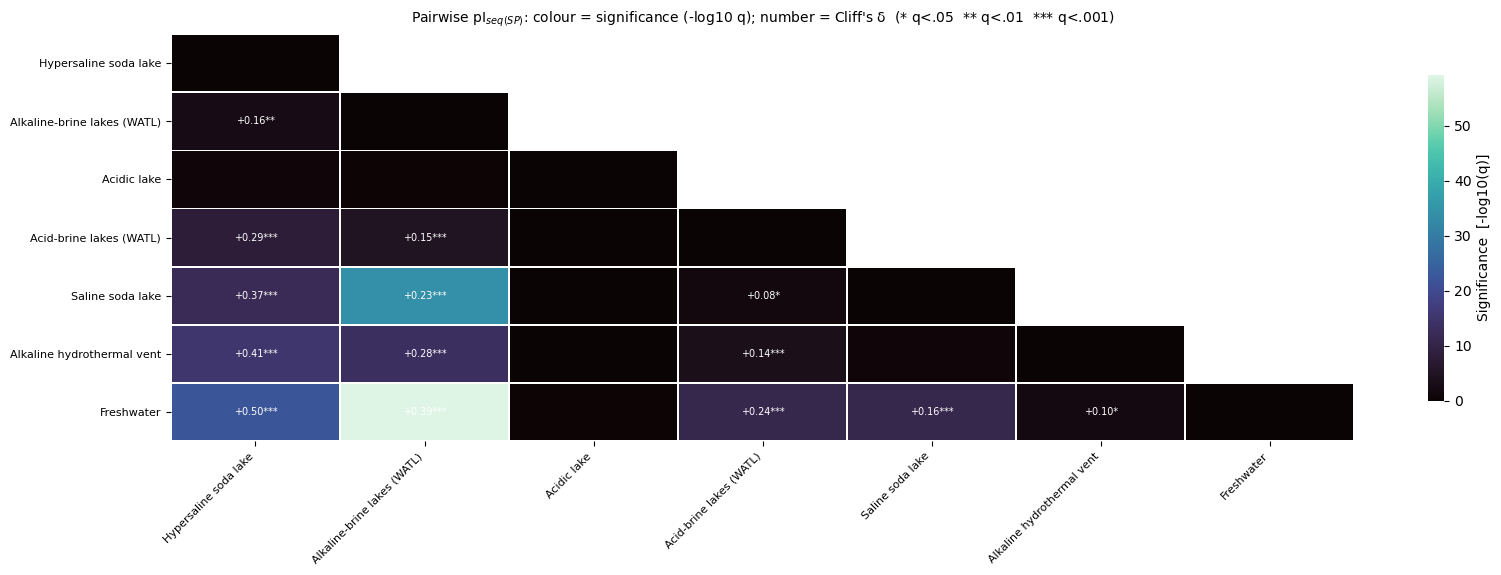

In [44]:

PANEL_W = 2.1   
PANEL_H = 0.55  

qmat = pd.DataFrame(1.0, index=envs, columns=envs)
for (a, b), q in padj.items():
    qmat.loc[a, b] = q; qmat.loc[b, a] = q
neglogq = -np.log10(qmat.clip(lower=1e-300))
mask = np.triu(np.ones(neglogq.shape, dtype=bool), k=1)      

# annotation = Cliff's delta and  stars for significance
annot = pd.DataFrame("", index=envs, columns=envs)
for (a, b), q in padj.items():
    st = "***" if q < .001 else "**" if q < .01 else "*" if q < .05 else ""
    if st:
        annot.loc[a, b] = f"{delta.loc[a, b]:+.2f}{st}"
        annot.loc[b, a] = f"{delta.loc[b, a]:+.2f}{st}"

plt.figure(figsize=(PANEL_W * len(envs) + 2, PANEL_H * len(envs) + 2))
ax = sns.heatmap(neglogq.astype(float), cmap="mako", mask=mask | neglogq.isna(),
                 linewidths=.5, linecolor="white",
                 annot=annot.values, fmt="", annot_kws={"size": 7, "color": "white"},
                 cbar_kws={"label": "Significance  [-log10(q)]", "shrink": 0.8})
ax.set_title("Pairwise pI$_{seq(SP)}$: colour = significance (-log10 q); "
             "number = Cliff's \u03b4  (* q<.05  ** q<.01  *** q<.001)", fontsize=10, pad=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("/Users/skoog/Desktop/panelD_significance_delta.svg", bbox_inches="tight", transparent=True)
plt.savefig("/Users/skoog/Desktop/panelD_significance_delta.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:

import os, glob, re
import pandas as pd

def canon(x):
    x = str(x)
    if x.endswith(".faa"):
        x = x[:-4]
    x = x.replace("|", "_")                          
    return re.sub(r"_provirus_\d+_\d+$", "", x)     

REV = "/Users/skoog/Desktop/Revisions"
SUMMARY = "all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_virus_summary.tsv"
SUMMARY_VS2 = "all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_virsorter2_virus_summary.tsv"  # new freshwater lakes

WATL_FAA_DIR         = f"{REV}/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit"
WATL_QUALITY_SUMMARY = f"{REV}/WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit/WATL_wet_dry_viruses_uniqueIDs_virus_summary.tsv"   # geNomad n_genes on WATLvirus IDs

ENV_STRUCT = {
    "WATL brine":                                      (WATL_FAA_DIR, WATL_QUALITY_SUMMARY),
    "Picturesque Lake":                                (f"{REV}/Picturesque_lake_split_by_contig_faa_updated_revisions_exact_besthit", SUMMARY),
    "Lake Tanatar trona crystallizer":                 (f"{REV}/Lake_tanatar_TC_split_by_contig_faa_updated_revisions_exact_besthit",  SUMMARY),
    "Lake Tanatar-5":                                  (f"{REV}/Tanatar_5_split_by_contig_faa_updated_revisions_exact_besthit",        SUMMARY),
    "Lake Bitter-1":                                   (f"{REV}/Lake_Bitter_1_split_by_contig_faa_updated_revisions_exact_besthit",    SUMMARY),
    "Cueva de la Mora lake - Chemocline (11m)":        (f"{REV}/Cueva_de_la_mora_lake_11m_split_by_contig_faa_updated_revisions_exact_besthit", SUMMARY),
    "Cueva de la Mora lake - Deep Anoxic Layer (35m)": (f"{REV}/Cueva_de_la_mora_lake_35m_split_by_contig_faa_updated_revisions_exact_besthit", SUMMARY),
    "Cueva de la Mora lake - Upper Oxic Layer (3m)":   (f"{REV}/Cueva_de_la_mora_lake_3m_split_by_contig_faa_updated_revisions_exact_besthit",  SUMMARY),
    "Cock Soda Lake":                                  (f"{REV}/Cock_soda_lake_split_by_contig_faa_updated_revisions_exact_besthit",   SUMMARY),
    "Lost City":                                       (f"{REV}/Lost_city_split_by_contig_faa_updated_revisions_exact_besthit",        SUMMARY),
    "Malaren B":                                       (f"{REV}/Malaren_B_split_by_contig_faa_updated_revisions_exact_besthit",       SUMMARY_VS2),
    "Lake Victoria":                                   (f"{REV}/Lake_Victoria_split_by_contig_faa_updated_revisions_exact_besthit",   SUMMARY_VS2),
    "Lake Soyang":                                     (f"{REV}/Lake_Soyang_viruses_split_by_contig_faa_besthit",       SUMMARY_VS2),
}

IMGVR_COMBINED_FAA = f"{REV}/all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_blast_vog_db_3_viral_structural_genes1_contigIDs_merged_viral_structural_genes_dir_updated_revisions_exact_besthit/viral_structural_genes_IMGVR_all_proteins_Freshwater_len3500_proteins.clean.faa"   # combined (NOT split per genome)
IMGVR_META         = f"{REV}/all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_blast_vog_db_3_viral_structural_genes1_contigIDs_merged_viral_structural_genes_dir_updated_revisions_exact_besthit/IMGVR_all_Sequence_information_Freshwater_len3500.tsv"
_UVIG_RE = re.compile(r"(IMGVR_UViG_\d+_\d+)")
def _parse_uvig(h):
    m = _UVIG_RE.search(str(h))
    if m: return m.group(1)
    p = str(h).split("_"); return "_".join(p[:4]) if len(p) > 4 else str(h)
def _n_structural_per_uvig_combined(faa):
    from collections import Counter
    c = Counter()
    for line in open(faa):
        if line.startswith(">"):
            c[_parse_uvig(line[1:].split()[0])] += 1
    return dict(c)

def _n_structural_per_contig(faa_dir):
    out = {}
    for fp in glob.glob(os.path.join(faa_dir, "*.faa")):
        base = os.path.basename(fp)
        if base.endswith(".faa"):
            base = base[:-4]
        full = base.replace("|", "_")          # FULL id (keeps provirus suffix) -> matches main pipeline
        out[full] = sum(1 for line in open(fp) if line.startswith(">"))
    return out

def _find_ngenes_col(df):
    for c in df.columns:
        if c.lower() in ("n_genes", "ngenes", "gene_count", "num_genes"):
            return c
    return None

def load_imgvr_meta(path):
    m = pd.read_csv(path, sep="\t")
    gene_col = next(c for c in m.columns if "gene content" in c.lower())
    out = pd.DataFrame({"contig_id": m[m.columns[0]].astype(str).map(canon)})
    out["n_genes"] = pd.to_numeric(m[gene_col].astype(str).str.split(";").str[0], errors="coerce")
    return out

def structural_orf_fraction(env_name):
    faa_dir, summ = ENV_STRUCT[env_name]
    summ_path = summ if os.path.isabs(summ) else os.path.join(faa_dir, summ)
    ns = _n_structural_per_contig(faa_dir)
    if not ns:
        print(f"[struct] {env_name}: no .faa in {faa_dir}"); return pd.DataFrame()
    try:
        s = pd.read_csv(summ_path, sep="\t")
    except FileNotFoundError:
        print(f"[struct] {env_name}: summary not found {summ_path}"); return pd.DataFrame()
    ng_col = _find_ngenes_col(s)
    if ng_col is None:
        print(f"[struct] {env_name}: no gene-count column (cols: {list(s.columns)[:8]}) -> skipped")
        return pd.DataFrame()
    s = s[[s.columns[0], ng_col]].copy(); s.columns = ["stripped_id", "n_genes"]
    s["stripped_id"] = s["stripped_id"].astype(str).map(canon)          # strip provirus suffix to match summary
    frac = pd.DataFrame({"contig_id": list(ns), "n_structural_orfs": list(ns.values())})
    frac["stripped_id"] = frac["contig_id"].map(canon)                  # temp key: strip only for the summary join
    frac = frac.merge(s, on="stripped_id", how="left").drop(columns="stripped_id")
    frac["n_genes"] = pd.to_numeric(frac["n_genes"], errors="coerce")
    frac["struct_orf_fraction"] = frac["n_structural_orfs"] / frac["n_genes"]
    frac["name_full"] = env_name
    n_anom = int((frac["n_structural_orfs"] > frac["n_genes"]).sum())
    msg = f"[struct] {env_name}: {len(frac)} genomes, median fraction = {frac['struct_orf_fraction'].median():.3f}"
    if n_anom: msg += f"  (!! {n_anom} with n_structural>n_genes -> check ID/ORF-caller match)"
    print(msg)
    return frac

def structural_orf_fraction_imgvr():
    try:
        ns = _n_structural_per_uvig_combined(IMGVR_COMBINED_FAA)
    except FileNotFoundError:
        print(f"[struct] Freshwater (IMG): combined faa not found {IMGVR_COMBINED_FAA}"); return pd.DataFrame()
    if not ns:
        print(f"[struct] Freshwater (IMG): no proteins parsed from {IMGVR_COMBINED_FAA}"); return pd.DataFrame()
    try:
        meta = load_imgvr_meta(IMGVR_META)
    except FileNotFoundError:
        print(f"[struct] Freshwater (IMG): metadata not found {IMGVR_META}"); return pd.DataFrame()
    frac = pd.DataFrame({"contig_id": list(ns), "n_structural_orfs": list(ns.values())}).merge(meta, on="contig_id", how="left")
    frac["struct_orf_fraction"] = frac["n_structural_orfs"] / frac["n_genes"]
    frac["name_full"] = "Freshwater (IMG)"
    print(f"[struct] Freshwater (IMG): {len(frac)} genomes, median fraction = {frac['struct_orf_fraction'].median():.3f}")
    return frac

struct_frac_all = pd.concat(
    [structural_orf_fraction(e) for e in ENV_STRUCT],
    ignore_index=True)
struct_frac_summary = (struct_frac_all.groupby("name_full")["struct_orf_fraction"]
                       .agg(["count", "median", "mean", "std"]).reset_index())
display(struct_frac_summary)
struct_frac_all.to_csv(f"{REV}/structural_orf_fraction_per_genome.csv", index=False)
print("wrote structural_orf_fraction_per_genome.csv")


/var/folders/cy/8q3xnh8d03z1c1c21dpxp6380000gn/T/ipykernel_41081/1819186065.py:90: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  s = pd.read_csv(summ_path, sep="\t")


[struct] WATL brine: 3466 genomes, median fraction = 0.167
[struct] Picturesque Lake: 52 genomes, median fraction = 0.167
[struct] Lake Tanatar trona crystallizer: 62 genomes, median fraction = 0.155
[struct] Lake Tanatar-5: 142 genomes, median fraction = 0.200
[struct] Lake Bitter-1: 14 genomes, median fraction = 0.143
[struct] Cueva de la Mora lake - Chemocline (11m): 10 genomes, median fraction = 0.134
[struct] Cueva de la Mora lake - Deep Anoxic Layer (35m): 5 genomes, median fraction = 0.154
[struct] Cueva de la Mora lake - Upper Oxic Layer (3m): 1 genomes, median fraction = 0.121
[struct] Cock Soda Lake: 1999 genomes, median fraction = 0.167
[struct] Lost City: 504 genomes, median fraction = 0.200
[struct] Malaren B: 526 genomes, median fraction = 0.167
[struct] Lake Victoria: 40 genomes, median fraction = 0.200
[struct] Lake Soyang: 650 genomes, median fraction = 0.143


,name_full,count,median,mean,std
0,Cock Soda Lake,1985,0.166667,0.200109,0.125894
1,Cueva de la Mora lake - Chemocline (11m),10,0.133929,0.164791,0.111040
2,Cueva de la Mora lake - Deep Anoxic Layer (35m),5,0.153846,0.172436,0.121277
3,Cueva de la Mora lake - Upper Oxic Layer (3m),1,0.121212,0.121212,NaN
4,Lake Bitter-1,14,0.142857,0.161036,0.067024
5,Lake Soyang,650,0.142857,0.162758,0.106846
6,Lake Tanatar trona crystallizer,62,0.154762,0.196791,0.123384
7,Lake Tanatar-5,142,0.200000,0.223276,0.123983
8,Lake Victoria,40,0.200000,0.263402,0.166778
9,Lost City,504,0.200000,0.229962,0.146854


wrote structural_orf_fraction_per_genome.csv


struct_frac_all: 7,471 rows, 7,469 unique contig_ids
structural-fraction coverage of analyzed genomes (0% => contig ids don't match this catalog):
Environment_Bin
Acid-brine lakes (WATL)           100%  (569/569)
Acidic lake                         100%  (16/16)
Alkaline hydrothermal vent        100%  (504/504)
Alkaline-brine lakes (WATL)     100%  (2536/2536)
Freshwater                      100%  (1206/1206)
Hypersaline soda lake             100%  (270/270)
Saline soda lake                100%  (1984/1984)

                               count      mean       50%       min       max
Environment_Bin                                                            
Acid-brine lakes (WATL)       569.0  0.258324  0.200000  0.010753  1.000000
Acidic lake                    16.0  0.164456  0.133929  0.014085  0.375000
Alkaline hydrothermal vent    504.0  0.229962  0.200000  0.003906  0.833333
Alkaline-brine lakes (WATL)  2536.0  0.204864  0.166667  0.003509  1.000000
Freshwater                   

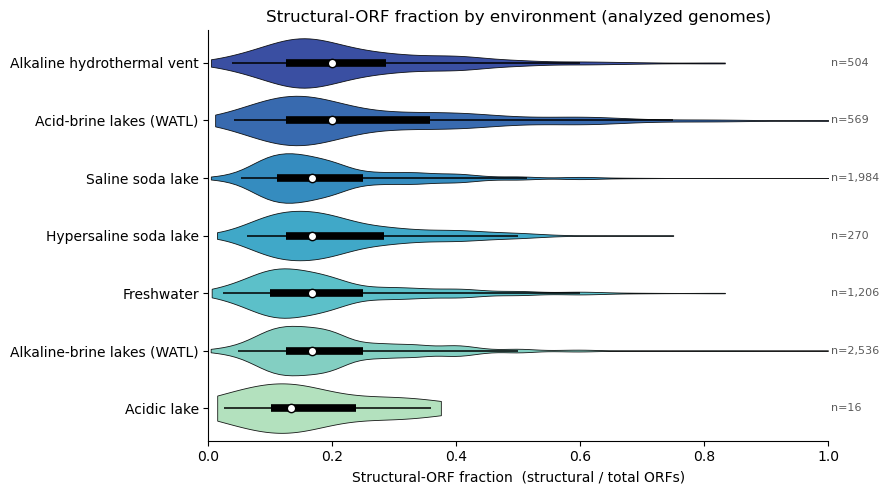


7,085 genomes with a structural fraction across 7 environments


In [46]:

import matplotlib.pyplot as plt
import pandas as pd, numpy as np

MAXPTS_KDE = 50_000   

analyzed = (filtered_All_envs_df_with_metadata.dropna(subset=["Median_pI", "Environment_Bin"])
            .query("Environment_Bin != 'Unclassified'")
            .drop_duplicates(["contig_id", "Environment_Bin"])[["contig_id", "Environment_Bin"]])
_sfa = struct_frac_all[["contig_id", "struct_orf_fraction"]].dropna().drop_duplicates("contig_id")
print(f"struct_frac_all: {len(struct_frac_all):,} rows, {struct_frac_all['contig_id'].nunique():,} unique contig_ids")
sf = analyzed.merge(_sfa, on="contig_id", how="left")

cov = sf.groupby("Environment_Bin")["struct_orf_fraction"].apply(
        lambda s: f"{s.notna().mean()*100:4.0f}%  ({s.notna().sum()}/{len(s)})")
print("structural-fraction coverage of analyzed genomes (0% => contig ids don't match this catalog):")
print(cov.to_string())

have = sf.dropna(subset=["struct_orf_fraction"])
if have.empty:
    print("\nNo structural fractions matched the analyzed genomes -- check contig-id match vs the panel-C catalog.")
else:
    order = have.groupby("Environment_Bin")["struct_orf_fraction"].median().sort_values().index.tolist()
    full  = [have.loc[have.Environment_Bin == e, "struct_orf_fraction"].values for e in order]
    ns    = [len(d) for d in full]
    rng   = np.random.default_rng(0)
    kde   = [d if len(d) <= MAXPTS_KDE else rng.choice(d, MAXPTS_KDE, replace=False) for d in full]

    print("\n", have.groupby("Environment_Bin")["struct_orf_fraction"].describe()[["count", "mean", "50%", "min", "max"]])

    fig, ax = plt.subplots(figsize=(9, max(3.6, 0.72 * len(order))))
    parts = ax.violinplot(kde, vert=False, showmedians=False, showextrema=False, widths=0.86)
    cmap = plt.cm.YlGnBu
    for i, b in enumerate(parts["bodies"]):
        b.set_facecolor(cmap(0.30 + 0.55 * i / max(1, len(order) - 1)))
        b.set_edgecolor("black"); b.set_alpha(0.9); b.set_linewidth(0.6)
    for i, d in enumerate(full, start=1):
        lo, q1, med, q3, hi = np.percentile(d, [2.5, 25, 50, 75, 97.5])
        ax.hlines(i, lo, hi, color="black", lw=1.1, zorder=3)
        ax.hlines(i, q1, q3, color="black", lw=5.5, zorder=4)
        ax.plot(med, i, "o", color="white", mec="black", ms=6, zorder=5)
    ax.set_yticks(range(1, len(order) + 1)); ax.set_yticklabels(order)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Structural-ORF fraction  (structural / total ORFs)")
    ax.set_title("Structural-ORF fraction by environment (analyzed genomes)")
    for i, n in enumerate(ns, start=1):
        ax.text(1.005, i, f"n={n:,}", va="center", ha="left", fontsize=8, color="0.35",
                transform=ax.get_yaxis_transform())
    ax.margins(y=0.02)
    plt.tight_layout()
    plt.savefig("/Users/skoog/Desktop/structural_orf_fraction_by_environment.svg", format="svg", bbox_inches="tight", transparent=True)
    plt.savefig("/Users/skoog/Desktop/structural_orf_fraction_by_environment.png", format="png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"\n{len(have):,} genomes with a structural fraction across {have['Environment_Bin'].nunique()} environments")

[checkv] Picturesque_lake                      :  1651 with completeness (1522 AAI, 129 HMM)
[checkv] Lake_Bitter_1                         :   540 with completeness (502 AAI, 38 HMM)
[checkv] Cock_soda_lake                        : 41189 with completeness (39168 AAI, 2021 HMM)
[checkv] Lake_tanatar_TC                       :  1664 with completeness (1584 AAI, 80 HMM)
[checkv] Tanatar_5                             :  2210 with completeness (0 AAI, 2210 HMM)
[checkv] Cueva_de_la_mora_lake_11m             :   256 with completeness (254 AAI, 2 HMM)
[checkv] Cueva_de_la_mora_lake_35m             :   369 with completeness (360 AAI, 9 HMM)
[checkv] Cueva_de_la_mora_lake_3m              :    58 with completeness (54 AAI, 4 HMM)
[checkv] Lost_city                             : 21600 with completeness (21007 AAI, 593 HMM)
[checkv] Malaren_B                             :  9388 with completeness (8923 AAI, 465 HMM)
[checkv] Lake_Victoria                         :  1030 with completeness (973 AAI,

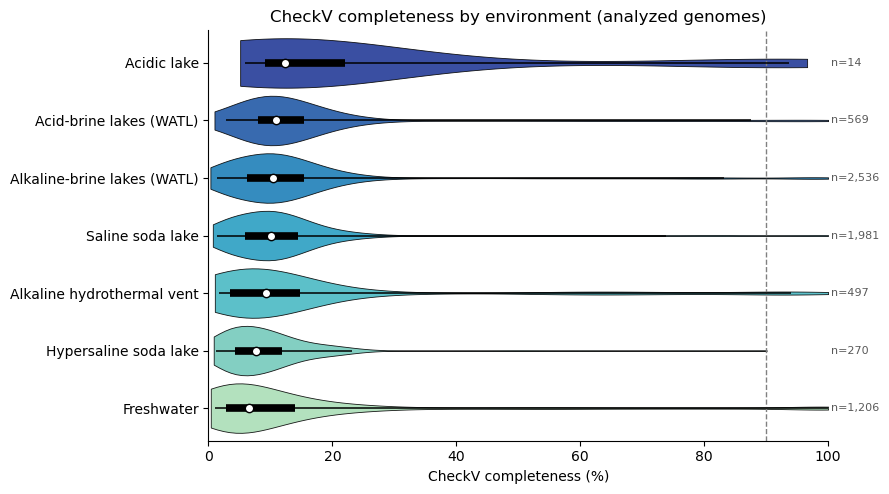

In [47]:

import os, re
import pandas as pd

def canon(x):
    x = str(x)
    if x.endswith(".faa"):
        x = x[:-4]
    return re.sub(r"_provirus_\d+_\d+$", "", x)

def _completeness_col(cols):
    low = {c.lower(): c for c in cols}
    for want in ("completeness", "aai_completeness"):
        if want in low:
            return low[want]
    cands = [c for c in cols if "completeness" in c.lower()
             and not any(k in c.lower() for k in ("lower", "upper", "method", "confidence"))]
    return cands[0] if cands else None

# CheckV completeness.tsv 
CHECKV_DIRS = {env: folder for env, (folder, _r) in RPKM_FILES.items()}
CHECKV_DIRS["WATL brine"] = "WATL_wet_dry_viruses_split_by_contig_faa_updated_revisions_besthit"   # EDIT if different
CHECKV_FILENAME = "completeness.tsv"
IMGVR_META = "/Users/skoog/Desktop/Revisions/all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_blast_vog_db_3_viral_structural_genes1_contigIDs_merged_viral_structural_genes_dir_updated_revisions_exact_besthit/IMGVR_all_Sequence_information_Freshwater_len3500.tsv"

KEY_TO_NAME = {
    "Picturesque_lake":          "Picturesque Lake",
    "Lake_tanatar_TC":           "Lake Tanatar trona crystallizer",
    "Tanatar_5":                 "Lake Tanatar-5",
    "Lake_Bitter_1":             "Lake Bitter-1",
    "Cueva_de_la_mora_lake_11m": "Cueva de la Mora lake - Chemocline (11m)",
    "Cueva_de_la_mora_lake_35m": "Cueva de la Mora lake - Deep Anoxic Layer (35m)",
    "Cueva_de_la_mora_lake_3m":  "Cueva de la Mora lake - Upper Oxic Layer (3m)",
    "Cock_soda_lake":            "Cock Soda Lake",
    "Lost_city":                 "Lost City",
    "Malaren_B":                 "Malaren B",
    "Lake_Victoria":             "Lake Victoria",
    "Lake_Soyang":               "Lake Soyang",
}
NAME_TO_KEY = {v: k for k, v in KEY_TO_NAME.items()}


def load_checkv(folder, label):
    path = os.path.join(REVISIONS, folder, CHECKV_FILENAME)
    try:
        q = pd.read_csv(path, sep="\t")
    except FileNotFoundError:
        print(f"[checkv] missing: {path}"); return pd.DataFrame()
    aai = pd.to_numeric(q.get("aai_completeness"), errors="coerce")
    lo  = pd.to_numeric(q.get("hmm_completeness_lower"), errors="coerce")
    hi  = pd.to_numeric(q.get("hmm_completeness_upper"), errors="coerce")
    comp = aai.fillna((lo + hi) / 2)          # AAI where available, HMM midpoint otherwise
    if comp.notna().sum() == 0:
        print(f"[checkv] no completeness in {path}"); return pd.DataFrame()
    out = pd.DataFrame({"src": label,
                        "contig_id": q[q.columns[0]].astype(str).map(canon),
                        "completeness": comp})
    print(f"[checkv] {label:38s}: {int(comp.notna().sum()):>5} with completeness "
          f"({int(aai.notna().sum())} AAI, {int((aai.isna() & comp.notna()).sum())} HMM)")
    return out

frames = [load_checkv(folder, label) for label, folder in CHECKV_DIRS.items()]
frames = [f for f in frames if not f.empty]
completeness_all = (pd.concat(frames, ignore_index=True)
                    .dropna(subset=["completeness"])
                    .drop_duplicates(["src", "contig_id"])          # dedup WITHIN a source, not globally
                    if frames else pd.DataFrame(columns=["src", "contig_id", "completeness"]))

analyzed = filtered_All_envs_df_with_metadata.dropna(subset=["Median_pI", "Environment_Bin"]).copy()
analyzed = analyzed[analyzed["Environment_Bin"] != "Unclassified"].drop_duplicates(["contig_id", "Environment_Bin"])
analyzed["src"] = analyzed["name_full"].map(NAME_TO_KEY)
analyzed.loc[analyzed["Environment_Bin"].str.contains("WATL", na=False), "src"] = "WATL brine"
_unmapped = sorted(set(analyzed.loc[analyzed["src"].isna(), "name_full"].dropna()))
if _unmapped:
    print("!! name_full with no src key (add to KEY_TO_NAME):", _unmapped)

# merge 
comp = analyzed.merge(completeness_all, on=["src", "contig_id"], how="left")

cov = comp.groupby("Environment_Bin")["completeness"].apply(lambda s: f"{s.notna().mean()*100:5.0f}%  ({s.notna().sum()}/{len(s)})")
print("\ncompleteness coverage (share of analyzed genomes with a CheckV value -- 0% means the\ncompleteness.tsv contig ids don't match this catalog's ids):")
print(cov.to_string())

# completeness distribution by environment 
have = comp.dropna(subset=["completeness"])
if not have.empty:
    import matplotlib.pyplot as plt
    import numpy as np
    MAXPTS_KDE = 50_000   # cap points fed to the KDE (density shape preserved); freshwater is ~1.7M
    print("\n", have.groupby("Environment_Bin")["completeness"].describe()[["count", "mean", "50%", "min", "max"]])
    order = have.groupby("Environment_Bin")["completeness"].median().sort_values().index.tolist()
    full  = [have.loc[have.Environment_Bin == e, "completeness"].values for e in order]
    ns    = [len(d) for d in full]
    rng   = np.random.default_rng(0)
    kde   = [d if len(d) <= MAXPTS_KDE else rng.choice(d, MAXPTS_KDE, replace=False) for d in full]
    cmap  = plt.cm.YlGnBu

    fig, ax = plt.subplots(figsize=(9, max(3.6, 0.72 * len(order))))
    valid = [(i + 1, kde[i]) for i in range(len(order)) if len(full[i]) >= 2]   # violins need >=2 points
    if valid:
        parts = ax.violinplot([k for _, k in valid], positions=[p for p, _ in valid],
                              vert=False, showmedians=False, showextrema=False, widths=0.86)
        for b, (p, _) in zip(parts["bodies"], valid):
            b.set_facecolor(cmap(0.30 + 0.55 * (p - 1) / max(1, len(order) - 1)))
            b.set_edgecolor("black"); b.set_alpha(0.9); b.set_linewidth(0.6)
    for i, d in enumerate(full, start=1):
        if len(d) == 0:
            continue
        lo, q1, med, q3, hi = np.percentile(d, [2.5, 25, 50, 75, 97.5])
        ax.hlines(i, lo, hi, color="black", lw=1.1, zorder=3)
        ax.hlines(i, q1, q3, color="black", lw=5.5, zorder=4)
        ax.plot(med, i, "o", color="white", mec="black", ms=6, zorder=5)
    ax.axvline(90, ls="--", lw=1, color="grey", zorder=2)
    ax.set_yticks(range(1, len(order) + 1)); ax.set_yticklabels(order)
    ax.set_xlim(0, 100)
    ax.set_xlabel("CheckV completeness (%)")
    ax.set_title("CheckV completeness by environment (analyzed genomes)")
    for i, n in enumerate(ns, start=1):
        ax.text(1.005, i, f"n={n:,}", va="center", ha="left", fontsize=8, color="0.35",
                transform=ax.get_yaxis_transform())
    ax.margins(y=0.02)
    plt.tight_layout()
    plt.savefig("/Users/skoog/Desktop/completeness_by_environment.svg", format="svg", bbox_inches="tight", transparent=True)
    plt.savefig("/Users/skoog/Desktop/completeness_by_environment.png", format="png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No completeness matched the analyzed genomes -- check that completeness.tsv contig ids match the catalog ids.")

#  completeness-matched subset 
COMPLETENESS_MIN = None      # set e.g. 50 or 90 to re-run panel C on a >= X% subset
if COMPLETENESS_MIN is not None and not completeness_all.empty:
    keep_ids = set(completeness_all.loc[completeness_all["completeness"] >= COMPLETENESS_MIN, "contig_id"])
    matched = filtered_All_envs_df_with_metadata[filtered_All_envs_df_with_metadata["contig_id"].isin(keep_ids)].copy()
    print(f"\ncompleteness-matched (>= {COMPLETENESS_MIN}%): {matched['contig_id'].nunique()} genomes "
          f"across {matched['Environment_Bin'].nunique()} environments")
    miss = set(have["Environment_Bin"].unique()) - set(matched["Environment_Bin"].unique())
    if miss:
        print(f"  NOTE: no >= {COMPLETENESS_MIN}% genomes remain in {sorted(miss)}")


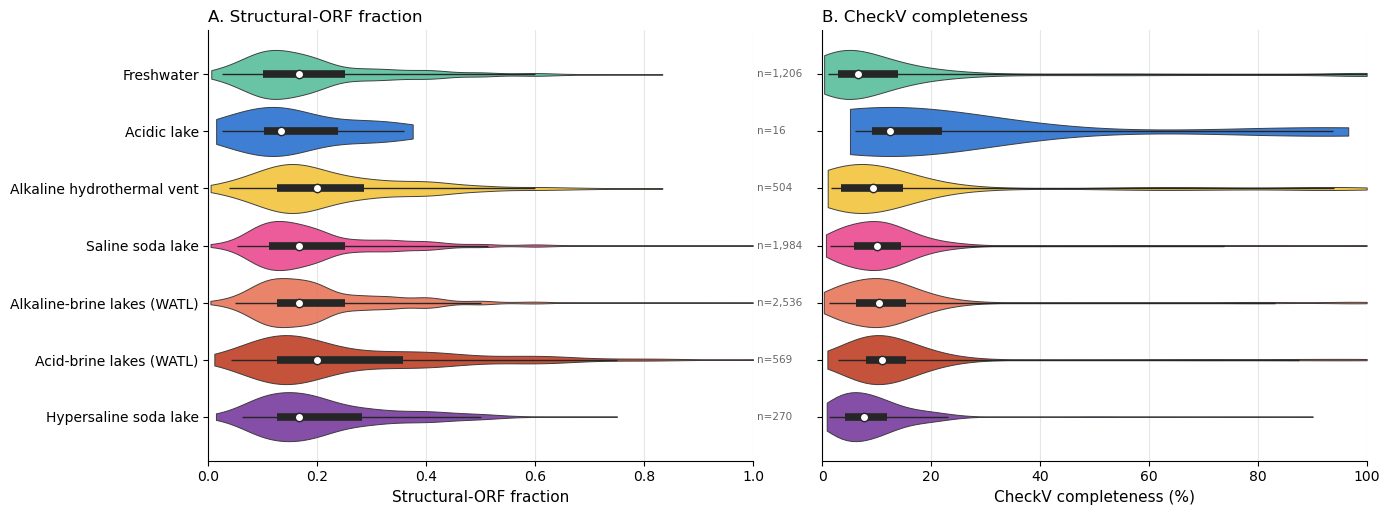

In [48]:

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd, numpy as np

MAXPTS_KDE = 50_000

# ---- one colour per environment type (Fig 3A family) ----
def env_color(e):
    s = str(e).casefold()
    if "freshwater" in s:                        return "#5CBF9E"   # green
    if "acidic" in s and "brine" not in s:       return "#2E74D0"   # blue (Cueva)
    if "vent" in s or "hydrothermal" in s:       return "#F2C640"   # gold (Lost City)
    if "saline soda" in s and "hyper" not in s:  return "#EC4E92"   # pink (Cock Soda)
    if "hypersaline soda" in s:                  return "#7B3FA0"   # purple (Tanatar/Bitter)
    if "acid-brine" in s or "acid brine" in s:   return "#C0442A"   # dark coral (WAHL)
    if "alkaline-brine" in s or "alkaline brine" in s: return "#E8785C"  # coral (WAHL)
    return "#BEBEBE"

analyzed = (filtered_All_envs_df_with_metadata.dropna(subset=["Median_pI", "Environment_Bin"])
            .query("Environment_Bin != 'Unclassified'")
            .drop_duplicates(["contig_id", "Environment_Bin"])[["contig_id", "Environment_Bin", "name_full"]])

KEY_TO_NAME = {
    "Picturesque_lake":"Picturesque Lake", "Lake_tanatar_TC":"Lake Tanatar trona crystallizer",
    "Tanatar_5":"Lake Tanatar-5", "Lake_Bitter_1":"Lake Bitter-1",
    "Cueva_de_la_mora_lake_11m":"Cueva de la Mora lake - Chemocline (11m)",
    "Cueva_de_la_mora_lake_35m":"Cueva de la Mora lake - Deep Anoxic Layer (35m)",
    "Cueva_de_la_mora_lake_3m":"Cueva de la Mora lake - Upper Oxic Layer (3m)",
    "Cock_soda_lake":"Cock Soda Lake", "Lost_city":"Lost City",
    "Malaren_B":"Malaren B", "Lake_Victoria":"Lake Victoria", "Lake_Soyang":"Lake Soyang",
}
NAME_TO_KEY = {v: k for k, v in KEY_TO_NAME.items()}
analyzed["src"] = analyzed["name_full"].map(NAME_TO_KEY)
analyzed.loc[analyzed["Environment_Bin"].str.contains("WATL", na=False), "src"] = "WATL brine"

def _mean_sal(e):
    g = filtered_All_envs_df_with_metadata
    g = g[g["Environment_Bin"] == e]
    lk = g.groupby("name_full")["Salinity"].first() if "name_full" in g.columns else g["Salinity"]
    s = pd.to_numeric(lk, errors="coerce").dropna()
    return np.nan if s.empty else float(s.mean())

sf = analyzed.merge(struct_frac_all[["contig_id","struct_orf_fraction"]].dropna()
                    .drop_duplicates("contig_id"), on="contig_id", how="left")
cv = analyzed.merge(completeness_all[["src","contig_id","completeness"]].dropna(),
                    on=["src","contig_id"], how="left")   # source-aware (fixes k141_* collisions)

panels = [(sf, "struct_orf_fraction", "Structural-ORF fraction", (0, 1),   None),
          (cv, "completeness",        "CheckV completeness (%)", (0, 100), None)]

envs_all = sorted(analyzed["Environment_Bin"].unique(),
                  key=lambda e: (-1 if np.isnan(_mean_sal(e)) else -_mean_sal(e)))

rng = np.random.default_rng(0)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})
fig, axes = plt.subplots(1, 2, figsize=(14, max(3.8, 0.75*len(envs_all))), sharey=True)

for ax, (dfm, col, xlab, xlim, refline) in zip(axes, panels):
    have = dfm.dropna(subset=[col])
    full = [have.loc[have.Environment_Bin==e, col].values for e in envs_all]
    ns   = [len(d) for d in full]
    valid = [(i+1, d if len(d)<=MAXPTS_KDE else rng.choice(d, MAXPTS_KDE, replace=False))
             for i,d in enumerate(full) if len(d) >= 2]
    if valid:
        parts = ax.violinplot([k for _,k in valid], positions=[p for p,_ in valid],
                              vert=False, showmedians=False, showextrema=False, widths=0.86)
        for b,(p,_) in zip(parts["bodies"], valid):
            b.set_facecolor(env_color(envs_all[p-1])); b.set_edgecolor("0.2")
            b.set_alpha(0.92); b.set_linewidth(0.7)
    for i,d in enumerate(full, start=1):
        if len(d)==0: continue
        lo,q1,med,q3,hi = np.percentile(d, [2.5,25,50,75,97.5])
        ax.hlines(i, lo, hi, color="0.15", lw=1.0, zorder=3)
        ax.hlines(i, q1, q3, color="0.15", lw=5.5, zorder=4)
        ax.plot(med, i, "o", color="white", mec="0.15", ms=6, zorder=5)
    if refline is not None:
        ax.axvline(refline, ls="--", lw=1, color="0.5", zorder=2)
    ax.set_xlim(*xlim); ax.set_xlabel(xlab, fontsize=11)
    ax.xaxis.grid(True, color="0.9", lw=0.8, zorder=0); ax.set_axisbelow(True)
    if col == "struct_orf_fraction":                # n= labels on panel A only
        for i,n in enumerate(ns, start=1):
            ax.text(1.008, i, f"n={n:,}", va="center", ha="left", fontsize=7.5, color="0.4",
                    transform=ax.get_yaxis_transform())

axes[0].set_yticks(range(1, len(envs_all)+1)); axes[0].set_yticklabels(envs_all, fontsize=10)
axes[0].set_title("A. Structural-ORF fraction", fontsize=12, loc="left")
axes[1].set_title("B. CheckV completeness", fontsize=12, loc="left")
fig.tight_layout()
plt.savefig("/Users/skoog/Desktop/SuppFig_structfrac_completeness.svg", bbox_inches="tight", transparent=True)
plt.savefig("/Users/skoog/Desktop/SuppFig_structfrac_completeness.png", dpi=300, bbox_inches="tight")
plt.show()

In [49]:
filtered_All_envs_df_with_metadata.to_pickle(
    "/Users/skoog/Desktop/Revisions/filtered_All_envs_df_with_metadata.pkl")
print("saved ->", "/Users/skoog/Desktop/Revisions/filtered_All_envs_df_with_metadata.pkl")

saved -> /Users/skoog/Desktop/Revisions/filtered_All_envs_df_with_metadata.pkl


In [50]:
v = (filtered_All_envs_df_with_metadata
     .query("Environment_Bin == 'Alkaline hydrothermal vent'")
     .drop_duplicates(["contig_id"]))
print(v.nlargest(10, "rpkm")[["contig_id", "family", "Median_pI", "rpkm"]])

          contig_id                       family  Median_pI        rpkm
16168     k141_2115  Unclassified Caudoviricetes   7.152233  2181.06900
16022   k141_490048   Unclassified Zobellviridae   4.440171  1060.65330
16288    k141_30729                 Microviridae   6.152503   808.74945
16152  k141_1992881                 Microviridae   6.317677   803.57630
16312   k141_346558                 Microviridae   6.317677   801.45404
15982   k141_798653                 Microviridae   6.317677   800.27680
16468   k141_430622                 Microviridae   6.317677   800.24370
16196   k141_410638                 Microviridae   6.390885   770.34894
16102   k141_366876                 Microviridae   6.317677   760.20160
16340    k141_37553                 Microviridae   6.317677   755.02850


In [51]:
v = (filtered_All_envs_df_with_metadata
     .query("Environment_Bin == 'Alkaline hydrothermal vent'")
     .drop_duplicates(["contig_id"]))
print("Microviridae share of vent genomes:",
      (v["family"] == "Microviridae").mean().round(3))
print("Microviridae share of vent RPKM:",
      v.loc[v["family"] == "Microviridae", "rpkm"].sum() / v["rpkm"].sum())
print(v.groupby("family")["Median_pI"].median().sort_values())

Microviridae share of vent genomes: 0.022
Microviridae share of vent RPKM: 0.24462191473578523
family
Phycodnaviridae                   4.078476
Unclassified Straboviridae        4.499795
Unclassified                      4.575221
Unclassified Demerecviridae       4.656046
Unclassified Chaseviridae         4.673510
Unclassified Herelleviridae       4.679918
Unclassified Schitoviridae        4.716636
Unclassified Zobellviridae        4.944106
Unclassified Autographiviridae    4.947886
Unclassified Caudoviricetes       5.074040
Microviridae                      6.317677
Tectiviridae                      6.985705
Corticoviridae                    7.303947
Name: Median_pI, dtype: float64


In [52]:
v = (filtered_All_envs_df_with_metadata
     .query("Environment_Bin == 'Alkaline hydrothermal vent'")
     .drop_duplicates(["contig_id"]))
print("vent genomes:", v["contig_id"].nunique(),
      "| unweighted median:", round(v["Median_pI"].median(), 2))
g = v.groupby("family").agg(n=("contig_id","nunique"),
                            rpkm=("rpkm","sum"),
                            med_pI=("Median_pI","median")).reset_index()
g["pct_genomes"] = (100*g["n"]/g["n"].sum()).round(1)
g["pct_rpkm"] = (100*g["rpkm"]/g["rpkm"].sum()).round(1)
print(g.sort_values("pct_rpkm", ascending=False)[
      ["family","n","pct_genomes","pct_rpkm","med_pI"]].to_string(index=False))

vent genomes: 504 | unweighted median: 5.07
                        family   n  pct_genomes  pct_rpkm   med_pI
   Unclassified Caudoviricetes 444         88.1      60.9 5.074040
                  Microviridae  11          2.2      24.5 6.317677
    Unclassified Zobellviridae   4          0.8       8.4 4.944106
                  Tectiviridae   9          1.8       3.2 6.985705
                Corticoviridae   4          0.8       0.8 7.303947
Unclassified Autographiviridae   7          1.4       0.7 4.947886
                  Unclassified   5          1.0       0.4 4.575221
   Unclassified Demerecviridae   5          1.0       0.3 4.656046
    Unclassified Straboviridae   5          1.0       0.3 4.499795
    Unclassified Schitoviridae   4          0.8       0.2 4.716636
               Phycodnaviridae   2          0.4       0.1 4.078476
     Unclassified Chaseviridae   2          0.4       0.1 4.673510
   Unclassified Herelleviridae   2          0.4       0.1 4.679918


vent genomes=504 | unweighted median=5.07 | weighted=6.15 | weighted w/o Microviridae=5.33


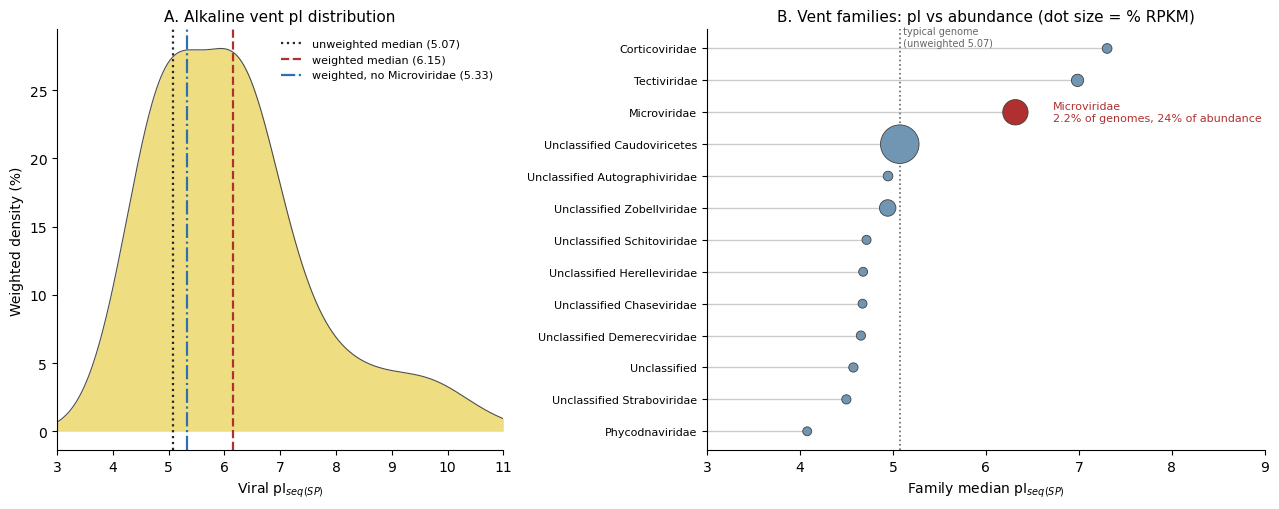

In [53]:

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
try:
    wquantile
except NameError:
    def wquantile(v, w, q):
        v=np.asarray(v,float); w=np.asarray(w,float)
        m=np.isfinite(v)&np.isfinite(w)&(w>0); v,w=v[m],w[m]
        if v.size==0: return np.nan
        o=np.argsort(v); v,w=v[o],w[o]; cw=(np.cumsum(w)-0.5*w)/w.sum()
        return float(np.interp(q, cw, v))

VENT = "Alkaline hydrothermal vent"
HILITE = "Microviridae"

v = (filtered_All_envs_df_with_metadata
     .query("Environment_Bin == @VENT")
     .drop_duplicates(["contig_id"]).copy())
v["Median_pI"] = pd.to_numeric(v["Median_pI"], errors="coerce")
v["rpkm"] = pd.to_numeric(v.get("rpkm", 1.0), errors="coerce").fillna(1.0).clip(lower=1e-9)
v = v.dropna(subset=["Median_pI"])

pi, w = v["Median_pI"].values, v["rpkm"].values
med_unw = float(np.median(pi))
med_w   = wquantile(pi, w, 0.50)
keep    = v["family"].astype(str) != HILITE
med_w_noMV = wquantile(v.loc[keep,"Median_pI"].values, v.loc[keep,"rpkm"].values, 0.50)
print(f"vent genomes={len(v)} | unweighted median={med_unw:.2f} | "
      f"weighted={med_w:.2f} | weighted w/o {HILITE}={med_w_noMV:.2f}")

g = (v.groupby("family").agg(n=("contig_id","nunique"), rpkm=("rpkm","sum"),
                             med=("Median_pI","median")).reset_index())
g["pct_gen"]  = 100*g["n"]/g["n"].sum()
g["pct_rpkm"] = 100*g["rpkm"]/g["rpkm"].sum()
g = g.sort_values("med")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios":[1, 1.25]})

x = np.linspace(3, 11, 400)
dens = gaussian_kde(pi, weights=w)(x) * 100
axA.fill_between(x, 0, dens, color="#EBD96B", alpha=0.85, linewidth=0)
axA.plot(x, dens, color="0.3", lw=0.8)
for val, ls, lab, col in [(med_unw, ":",  f"unweighted median ({med_unw:.2f})", "0.15"),
                          (med_w,   "--", f"weighted median ({med_w:.2f})", "#B03030"),
                          (med_w_noMV,"-.",f"weighted, no {HILITE} ({med_w_noMV:.2f})", "#2E6FB0")]:
    axA.axvline(val, ls=ls, lw=1.6, color=col, label=lab)
axA.set_xlabel("Viral pI$_{seq(SP)}$"); axA.set_ylabel("Weighted density (%)")
axA.set_title("A. Alkaline vent pI distribution", fontsize=11)
axA.set_xlim(3, 11); axA.legend(fontsize=8, frameon=False, loc="upper right")

ypos = np.arange(len(g))
sizes = 40 + 12*g["pct_rpkm"].values
colors = ["#B03030" if f == HILITE else "#7196B3" for f in g["family"]]
axB.hlines(ypos, 3, g["med"].values, color="0.8", lw=1, zorder=1)
axB.scatter(g["med"].values, ypos, s=sizes, c=colors, edgecolor="0.25", lw=0.6, zorder=3)
axB.axvline(med_unw, ls=":", color="0.4", lw=1.2)
axB.text(med_unw, len(g)-0.3, f" typical genome\n (unweighted {med_unw:.2f})", fontsize=7, color="0.4", va="top")
for i, r in enumerate(g.itertuples()):
    if r.family == HILITE:
        axB.annotate(f"{r.family}\n{r.pct_gen:.1f}% of genomes, {r.pct_rpkm:.0f}% of abundance",
                     (r.med, i), xytext=(r.med+0.4, i), fontsize=8, va="center", color="#B03030")
axB.set_yticks(ypos); axB.set_yticklabels(g["family"], fontsize=8)
axB.set_xlabel("Family median pI$_{seq(SP)}$"); axB.set_xlim(3, 9)
axB.set_title("B. Vent families: pI vs abundance (dot size = % RPKM)", fontsize=11)

plt.tight_layout()
plt.savefig("/Users/skoog/Desktop/SuppFig_vent_microviridae.svg", bbox_inches="tight", transparent=True)
plt.savefig("/Users/skoog/Desktop/SuppFig_vent_microviridae.png", dpi=300, bbox_inches="tight")
plt.show()